# PennyLane Codebook Solutions
**Student:** JOAQUIN GABRIEL MARQUEZ OLGUIN

**Course:** 2025/26

In [ ]:
# Standard quantum computing packages
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
import fractions
import random

# Set random seed for reproducibility
np.random.seed(42)

## 1. Introduction to Quantum Computing
### All About Qubits

In [ ]:
"""
1.1.1 Normalization of quantum states
"""
# Here are the vector representations of |0> and |1>, for convenience
ket_0 = np.array([1, 0])
ket_1 = np.array([0, 1])


def normalize_state(alpha, beta):
    """Compute a normalized quantum state given arbitrary amplitudes.

    Args:
        alpha (complex): The amplitude associated with the |0> state.
        beta (complex): The amplitude associated with the |1> state.

    Returns:
        np.array[complex]: A vector (numpy array) with 2 elements that represents
        a normalized quantum state.
    """

    psi = alpha * ket_0 + beta * ket_1
    norm = np.sqrt(np.abs(alpha**2) + np.abs(beta**2))

    return psi / norm

"""
1.1.2 Inner product and orthonormal bases
"""
def inner_product(state_1, state_2):
    """Compute the inner product between two states.

    Args:
        state_1 (np.array[complex]): A normalized quantum state vector
        state_2 (np.array[complex]): A second normalized quantum state vector

    Returns:
        complex: The value of the inner product <state_1 | state_2>.
    """

    # Altervative solution: sol = np.dot(np.conj(state_1), state_2)

    return np.vdot(state_1, state_2)


# Test your results with this code
ket_0 = np.array([1, 0])
ket_1 = np.array([0, 1])

print(f"<0|0> = {inner_product(ket_0, ket_0)}")
print(f"<0|1> = {inner_product(ket_0, ket_1)}")
print(f"<1|0> = {inner_product(ket_1, ket_0)}")
print(f"<1|1> = {inner_product(ket_1, ket_1)}")

"""
1.1.3 Sampling measurement outcomes
"""
def measure_state(state, num_meas):
    """Simulate a quantum measurement process.

    Args:
        state (np.array[complex]): A normalized qubit state vector.
        num_meas (int): The number of measurements to take

    Returns:
        np.array[int]: A set of num_meas samples, 0 or 1, chosen according to the probability
        distribution defined by the input state.
    """

    # Compute probabilities
    p_alpha = np.abs(state[0]**2)
    p_beta = np.abs(state[1]**2)
    
    # np.random.choice(a, size=None, replace=True, p=None) where p is the probs. associated to each a
    samples = np.random.choice([0, 1], size = num_meas, p = [p_alpha, p_beta])

    return samples

"""
1.1.4 Applying a quantum operation
"""
def measure_state(state, num_meas):
    """Simulate a quantum measurement process.

    Args:
        state (np.array[complex]): A normalized qubit state vector.
        num_meas (int): The number of measurements to take

    Returns:
        np.array[int]: A set of num_meas samples, 0 or 1, chosen according to the probability
        distribution defined by the input state.
    """

    # Compute probabilities
    p_alpha = np.abs(state[0]**2)
    p_beta = np.abs(state[1]**2)
    
    # np.random.choice(a, size=None, replace=True, p=None) where p is the probs. associated to each a
    samples = np.random.choice([0, 1], size = num_meas, p = [p_alpha, p_beta])

    return samples

"""
1.1.5 A simple quantum algorithm
"""
U = np.array([[1, 1], [1, -1]]) / np.sqrt(2)


def initialize_state():
    """Prepare a qubit in state |0>.

    Returns:
        np.array[float]: the vector representation of state |0>.
    """
    initial_state = np.array([1, 0])
    return initial_state


def apply_u(state):
    """Apply a quantum operation."""
    return np.dot(U, state)


def measure_state(state, num_meas):
    """Measure a quantum state num_meas times."""
    p_alpha = np.abs(state[0]) ** 2
    p_beta = np.abs(state[1]) ** 2
    meas_outcome = np.random.choice([0, 1], p=[p_alpha, p_beta], size=num_meas)
    return meas_outcome


def quantum_algorithm():
    """Use the functions above to implement the quantum algorithm described above.

    Try and do so using three lines of code or less!

    Returns:
        np.array[int]: the measurement results after running the algorithm 100 times
    """
    return measure_state(apply_u(initialize_state()), 100)

quantum_algorithm()


### Quantum Circuits

In [ ]:
"""
1.2.1 Order of operations
"""
def my_circuit(theta, phi):
    qml.CNOT(wires=[0, 1])
    qml.RX(theta, wires=2)
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[2, 0])
    qml.RY(phi, wires=1)

    # This is the measurement; we return the probabilities of all possible output states
    return qml.probs(wires=[0, 1, 2])


"""
1.2.2 Building a QNode
"""
# This creates a device with three wires on which PennyLane can run computations
dev = qml.device("default.qubit", wires=3)


def my_circuit(theta, phi, omega):
    qml.RX(theta, wires = 0)
    qml.RY(phi, wires = 1)
    qml.RZ(omega, wires = 2)

    qml.CNOT(wires = [0, 1])
    qml.CNOT(wires = [1, 2])
    qml.CNOT(wires = [2, 0])

    return qml.probs(wires=[0, 1, 2])


# This creates a QNode, binding the function and device
my_qnode = qml.QNode(my_circuit, dev)

# We set up some values for the input parameters
theta, phi, omega = 0.1, 0.2, 0.3

# Now we can execute the QNode by calling it like we would a regular function
my_qnode(theta, phi, omega)

"""
1.2.3 The QNode decorator
"""
dev = qml.device("default.qubit", wires=3)

@qml.qnode(dev)
def my_circuit(theta, phi, omega):
    qml.RX(theta, wires=0)
    qml.RY(phi, wires=1)
    qml.RZ(omega, wires=2)
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 2])
    qml.CNOT(wires=[2, 0])
    return qml.probs(wires=[0, 1, 2])


theta, phi, omega = 0.1, 0.2, 0.3

# Run simulation
my_circuit(theta, phi, omega)

"""
1.2.4 Circuit depth
"""
dev = qml.device("default.qubit", wires=3)


@qml.qnode(dev)
def my_circuit(theta, phi, omega):
    qml.RX(theta, wires=0)
    qml.RY(phi, wires=1)
    qml.RZ(omega, wires=2)
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 2])
    qml.CNOT(wires=[2, 0])
    return qml.probs(wires=[0, 1, 2])


depth = 4


### Unitary Matrices

In [ ]:
"""
1.3.1 Unitaries in PennyLane
"""
dev = qml.device("default.qubit", wires=1)

U = np.array([[1, 1], [1, -1]]) / np.sqrt(2)


@qml.qnode(dev)
def apply_u():

    qml.QubitUnitary(U, wires=0)

    # Return the state
    return qml.state()

"""
1.3.2 Parametrized unitaries
"""
dev = qml.device("default.qubit", wires=1)


@qml.qnode(dev)
def apply_u_as_rot(phi, theta, omega):

    ##################
    # YOUR CODE HERE #
    ##################

    # APPLY A ROT GATE USING THE PROVIDED INPUT PARAMETERS

    qml.Rot(phi, theta, omega, wires=0)

    # RETURN THE QUANTUM STATE VECTOR

    return qml.state()


### Single-Qubit Gates

In [ ]:
"""
1.4.1 Flipping bits
"""
dev = qml.device("default.qubit", wires=1)


@qml.qnode(dev)
def apply_u_as_rot(phi, theta, omega):

    ##################
    # YOUR CODE HERE #
    ##################

    # APPLY A ROT GATE USING THE PROVIDED INPUT PARAMETERS

    qml.Rot(phi, theta, omega, wires=0)

    # RETURN THE QUANTUM STATE VECTOR

    return qml.state()

"""
1.4.2 Uniform superposition
"""
dev = qml.device("default.qubit", wires=1)


@qml.qnode(dev)
def apply_hadamard():
    ##################
    # YOUR CODE HERE #
    ##################

    # APPLY THE HADAMARD GATE
    qml.Hadamard(wires=0)

    # RETURN THE STATE
    return qml.state()

"""
1.4.3 Combining X and H
"""
dev = qml.device("default.qubit", wires=1)


@qml.qnode(dev)
def apply_hadamard_to_state(state):
    """Complete the function such that we can apply the Hadamard to
    either |0> or |1> depending on the input argument flag.

    Args:
        state (int): Either 0 or 1. If 1, prepare the qubit in state |1>,
            otherwise, leave it in state 0.

    Returns:
        np.array[complex]: The state of the qubit after the operations.
    """
    ##################
    # YOUR CODE HERE #
    ##################

    # KEEP THE QUBIT IN |0> OR CHANGE IT TO |1> DEPENDING ON state
    if state==1:
        qml.PauliX(wires=0)

    # APPLY THE HADAMARD
    qml.Hadamard(wires=0)

    # RETURN THE STATE

    return qml.state()


print(apply_hadamard_to_state(0))
print(apply_hadamard_to_state(1))

"""
1.4.4 A QNode with X and H
"""
##################
# YOUR CODE HERE #
##################

# CREATE A DEVICE
dev = qml.device('default.qubit', wires=1)

# CREATE A QNODE CALLED apply_hxh THAT APPLIES THE CIRCUIT ABOVE
@qml.qnode(dev)
def apply_hxh(state):
    if state==1:
        qml.PauliX(wires=0)

    qml.Hadamard(wires=0)
    qml.PauliX(wires=0)
    qml.Hadamard(wires=0)


    return qml.state()

# Print your results
print(apply_hxh(0))
print(apply_hxh(1))


### It's Just a Phase

In [ ]:
"""
1.5.1 The Pauli Z gate
"""
dev = qml.device("default.qubit", wires=1)


@qml.qnode(dev)
def apply_z_to_plus():
    """Write a circuit that applies PauliZ to the |+> state and returns
    the state.

    Returns:
        np.array[complex]: The state of the qubit after the operations.
    """

    ##################
    # YOUR CODE HERE #
    ##################

    # CREATE THE |+> STATE
    qml.Hadamard(wires=0)

    # APPLY PAULI Z
    qml.PauliZ(wires=0)

    # RETURN THE STATE
    return qml.state()


print(apply_z_to_plus())

"""
1.5.2 The Z rotation
"""
dev = qml.device("default.qubit", wires=1)


@qml.qnode(dev)
def fake_z():
    """Use RZ to produce the same action as Pauli Z on the |+> state.

    Returns:
        np.array[complex]: The state of the qubit after the operations.
    """

    ##################
    # YOUR CODE HERE #
    ##################

    # CREATE THE |+> STATE
    qml.Hadamard(wires=0)

    # APPLY RZ (with angle = pi)
    qml.RZ(np.pi, wires=0)

    # RETURN THE STATE
    return qml.state()

"""
1.5.3 The S and T gates
"""
dev = qml.device("default.qubit", wires=1)


@qml.qnode(dev)
def many_rotations():
    """Implement the circuit depicted above and return the quantum state.

    Returns:
        np.array[complex]: The state of the qubit after the operations.
    """

    ##################
    # YOUR CODE HERE #
    ##################

    # IMPLEMENT THE CIRCUIT
    qml.Hadamard(wires=0)
    qml.S(wires=0)
    qml.adjoint(qml.T)(wires=0)
    qml.RZ(0.3, wires=0)
    qml.adjoint(qml.S)(wires=0)

    # RETURN THE STATE

    return qml.state()


### From a Different Angle

In [ ]:
"""
1.6.1 Applying RX
"""
dev = qml.device("default.qubit", wires=1)


@qml.qnode(dev)
def apply_rx_pi(state):
    """Apply an RX gate with an angle of \pi to a particular basis state.

    Args:
        state (int): Either 0 or 1. If 1, initialize the qubit to state |1>
            before applying other operations.

    Returns:
        np.array[complex]: The state of the qubit after the operations.
    """
    if state == 1:
        qml.PauliX(wires=0)

    ##################
    # YOUR CODE HERE #
    ##################

    # APPLY RX(pi) AND RETURN THE STATE
    qml.RX(np.pi, wires=0)

    return qml.state()


print(apply_rx_pi(0))
print(apply_rx_pi(1))

"""
1.6.2 Plotting RX
"""
dev = qml.device("default.qubit", wires=1)


@qml.qnode(dev)
def apply_rx(theta, state):
    """Apply an RX gate with an angle of theta to a particular basis state.

    Args:
        theta (float): A rotation angle.
        state (int): Either 0 or 1. If 1, initialize the qubit to state |1>
            before applying other operations.

    Returns:
        np.array[complex]: The state of the qubit after the operations.
    """
    if state == 1:
        qml.PauliX(wires=0)

    ##################
    # YOUR CODE HERE #
    ##################

    # APPLY RX(theta) AND RETURN THE STATE
    qml.RX(theta, wires=0)

    return qml.state()


# Code for plotting
angles = np.linspace(0, 4 * np.pi, 200)
output_states = np.array([apply_rx(t, 0) for t in angles])

plot = plotter(angles, output_states)

"""
1.6.3 Plotting RY
"""
dev = qml.device("default.qubit", wires=1)


@qml.qnode(dev)
def apply_ry(theta, state):
    """Apply an RY gate with an angle of theta to a particular basis state.

    Args:
        theta (float): A rotation angle.
        state (int): Either 0 or 1. If 1, initialize the qubit to state |1>
            before applying other operations.

    Returns:
        np.array[complex]: The state of the qubit after the operations.
    """
    if state == 1:
        qml.PauliX(wires=0)

    ##################
    # YOUR CODE HERE #
    ##################

    # APPLY RY(theta) AND RETURN THE STATE
    qml.RY(theta, wires=0)

    return qml.state()


# Code for plotting
angles = np.linspace(0, 4 * np.pi, 200)
output_states = np.array([apply_ry(t, 0) for t in angles])

plot = plotter(angles, output_states)


### Universal Gate Sets

In [ ]:
"""
1.7.1 Universality of rotations
"""
dev = qml.device("default.qubit", wires=1)

##################
# YOUR CODE HERE #
##################

# ADJUST THE VALUES OF PHI, THETA, AND OMEGA
phi, theta, omega = np.pi/2, np.pi/2, np.pi/2


@qml.qnode(dev)
def hadamard_with_rz_rx():
    qml.RZ(phi, wires=0)
    qml.RX(theta, wires=0)
    qml.RZ(omega, wires=0)
    return qml.state()

# note: using only RX(pi/2) does not work because we have to take into account the relative phases!

"""
1.7.2 Synthesizing a circuit
"""
dev = qml.device("default.qubit", wires=1)


@qml.qnode(dev)
def convert_to_rz_rx():
    ##################
    # YOUR CODE HERE #
    ##################

    # Hadamard gate
    qml.RZ(np.pi/2, wires=0)
    qml.RX(np.pi/2, wires=0)
    qml.RZ(np.pi/2, wires=0)

    # S gate
    qml.RZ(np.pi/2, wires=0)

    # T* gate
    qml.RZ(-np.pi/4, wires=0) # alternative: qml.adjoint(qml.RZ)(np.pi/4, wires=0)

    # Y gate: rotate Z axis so Y axis is where X axis used to be, and then revert the first rot.
    qml.RZ(np.pi/2, wires=0)
    qml.RX(np.pi, wires=0) # rotation of 180º
    qml.RZ(-np.pi/2, wires=0)
    # note: RZ(pi/2) RX(pi) RZ(-pi/2) = RZ(pi/2) RZ(pi/2) RX(pi) = RZ(pi) RX(pi)

    return qml.state()

"""
1.7.3 Universality of H and T
"""
dev = qml.device("default.qubit", wires=1)

# NOTES: 
# 1. The normalization factor 1/sqrt(2)^3 means we have to apply 3 H gates (which introduce a factor of 1/sqrt(2))
# 2. T gate produces factors of exp(i pi/4); T^2 = S gate produces factors of i = exp(i pi/2)
# 3. Arbitraty rot. usual structure: H -> phase -> H -> phase -> H

@qml.qnode(dev)
def unitary_with_h_and_t():
    ##################
    # YOUR CODE HERE #
    ##################

    # APPLY ONLY H AND T TO PRODUCE A CIRCUIT THAT EFFECTS THE GIVEN MATRIX
    qml.Hadamard(wires=0)
    qml.T(wires=0)
    qml.Hadamard(wires=0)
    qml.T(wires=0)
    qml.T(wires=0)
    qml.Hadamard(wires=0)

    return qml.state()


### Prepare Yourself

In [ ]:
"""
1.8.1 State preparation
"""
dev = qml.device("default.qubit", wires=1)


@qml.qnode(dev)
def prepare_state():
    ##################
    # YOUR CODE HERE #
    ##################

    # APPLY OPERATIONS TO PREPARE THE TARGET STATE
    qml.Hadamard(wires=0)
    qml.RZ(5 * np.pi / 4, wires=0)

    return qml.state()

"""
1.8.2 State preparation revisited
"""
dev = qml.device("default.qubit", wires=1)


@qml.qnode(dev)
def prepare_state():
    ##################
    # YOUR CODE HERE #
    ##################

    # APPLY OPERATIONS TO PREPARE THE TARGET STATE
    qml.RX(np.pi / 3, wires=0) # sin(pi/6) = 1/2, cos(pi/6) = sqrt(3)/2

    return qml.state()

"""
1.8.3 State preparation with Mottonen's method
"""
v = np.array([0.52889389 - 0.14956775j, 0.67262317 + 0.49545818j])

##################
# YOUR CODE HERE #
##################

# CREATE A DEVICE

dev = qml.device("default.qubit", wires=1)


# CONSTRUCT A QNODE THAT USES qml.MottonenStatePreparation
# TO PREPARE A QUBIT IN STATE V, AND RETURN THE STATE

@qml.qnode(dev)
def prepare_state(state=v):
    qml.MottonenStatePreparation(state, wires=0)
    return qml.state()


# This will draw the quantum circuit and allow you to inspect the output gates
print(prepare_state(v))
print()
print(qml.draw(prepare_state, level="device")(v))


### Measurements

In [ ]:
"""
1.9.1 Measuring a superposition
"""
dev = qml.device("default.qubit", wires=1)


@qml.qnode(dev)
def apply_h_and_measure(state):
    """Complete the function such that we apply the Hadamard gate
    and measure in the computational basis.

    Args:
        state (int): Either 0 or 1. If 1, prepare the qubit in state |1>,
            otherwise leave it in state 0.

    Returns:
        np.array[float]: The measurement outcome probabilities.
    """
    if state == 1:
        qml.PauliX(wires=0)

    ##################
    # YOUR CODE HERE #
    ##################

    # APPLY HADAMARD AND MEASURE
    qml.Hadamard(wires=0)

    return qml.probs(wires=0)


print(apply_h_and_measure(0))
print(apply_h_and_measure(1))

"""
1.9.2 Y basis rotation
"""
##################
# YOUR CODE HERE #
##################

state = np.array([0.5 +0j, 0+np.sqrt(3)/2j])

# WRITE A QUANTUM FUNCTION THAT PREPARES (1/2)|0> + i(sqrt(3)/2)|1>
def prepare_psi():
    qml.RX(-2 * np.pi / 3, wires=0)
    # qml.MottonenStatePreparation(state, wires = 0)


# WRITE A QUANTUM FUNCTION THAT SENDS BOTH |0> TO |y_+> and |1> TO |y_->
def y_basis_rotation():
    qml.Hadamard(wires=0)
    qml.S(wires=0)

"""
1.9.3 Measuring in the Y basis
"""
dev = qml.device("default.qubit", wires=1)


@qml.qnode(dev)
def measure_in_y_basis():
    ##################
    # YOUR CODE HERE #
    ##################

    # You do not go "to the Y basis." 
    # You rotate the Y-basis back to the computational basis so the dumb hardware can read it.

    # PREPARE THE STATE
    prepare_psi()

    # PERFORM THE ROTATION BACK TO COMPUTATIONAL BASIS
    qml.adjoint(y_basis_rotation)()

    # RETURN THE MEASUREMENT OUTCOME PROBABILITIES

    return qml.probs(wires=0)


print(measure_in_y_basis())


### What Did You Expect?

In [ ]:
"""
1.10.1 Measuring of the PauliY operator
"""
dev = qml.device("default.qubit", wires=1)


@qml.qnode(dev)
def circuit():
    ##################
    # YOUR CODE HERE #
    ##################

    # IMPLEMENT THE CIRCUIT IN THE PICTURE AND MEASURE PAULI Y
    qml.RX(np.pi/4, wires=0)
    qml.Hadamard(wires=0)
    qml.PauliZ(wires=0)

    return qml.expval(qml.PauliY(wires=0))


print(circuit())

"""
1.10.2 Setting up the number of experiment shots
"""
# An array to store your results
shot_results = []

# Different numbers of shots
shot_values = [100, 1000, 10000, 100000, 1000000]

for shots in shot_values:
    ##################
    # YOUR CODE HERE #
    ##################

    # CREATE A DEVICE, CREATE A QNODE, AND RUN IT
    dev = qml.device('default.qubit', wires=1, shots=shots)

    @qml.qnode(dev)
    def circuit():
        qml.RX(np.pi/4, wires=0)
        qml.Hadamard(wires=0)
        qml.PauliZ(wires=0)
        return qml.expval(qml.PauliY(wires=0))
      

    shot_results.append(circuit())

print(qml.math.unwrap(shot_results))

"""
1.10.3 Evaluating the samples
"""
dev = qml.device("default.qubit", wires=1, shots=100000)


@qml.qnode(dev)
def circuit():
    qml.RX(np.pi / 4, wires=0)
    qml.Hadamard(wires=0)
    qml.PauliZ(wires=0)

    ##################
    # YOUR CODE HERE #
    ##################

    # RETURN THE MEASUREMENT SAMPLES OF THE CORRECT OBSERVABLE

    return qml.sample(qml.PauliY(wires=0))


def compute_expval_from_samples(samples):
    """Compute the expectation value of an observable given a set of
    sample outputs. You can assume that there are two possible outcomes,
    1 and -1.

    Args:
        samples (np.array[float]): 100000 samples representing the results of
            running the above circuit.

    Returns:
        float: the expectation value computed based on samples.
    """

    estimated_expval = 0

    ##################
    # YOUR CODE HERE #
    ##################

    # USE THE SAMPLES TO ESTIMATE THE EXPECTATION VALUE
    for sample in samples:
        estimated_expval += sample

    return estimated_expval / len(samples)


samples = circuit()
print(compute_expval_from_samples(samples))

"""
1.10.4 The variance of sample measurements
"""
def variance_experiment(n_shots):
    """Run an experiment to determine the variance in an expectation
    value computed with a given number of shots.

    Args:
        n_shots (int): The number of shots

    Returns:
        float: The variance in expectation value we obtain running the
        circuit 100 times with n_shots shots each.
    """

    # To obtain a variance, we run the circuit multiple times at each shot value.
    n_trials = 100

    ##################
    # YOUR CODE HERE #
    ##################

    # CREATE A DEVICE WITH GIVEN NUMBER OF SHOTS

    dev = qml.device('default.qubit', wires=1, shots=n_shots)

    # DECORATE THE CIRCUIT BELOW TO CREATE A QNODE
    @qml.qnode(dev)
    def circuit():
        qml.Hadamard(wires=0)
        return qml.expval(qml.PauliZ(wires=0))

    # RUN THE QNODE N_TRIALS TIMES AND RETURN THE VARIANCE OF THE RESULTS
    exp_vals = [circuit() for _ in range(n_trials)]
    return np.var(exp_vals)


def variance_scaling(n_shots):
    """Once you have determined how the variance in expectation value scales
    with the number of shots, complete this function to programmatically
    represent the relationship.

    Args:
        n_shots (int): The number of shots

    Returns:
        float: The variance in expectation value we expect to see when we run
        an experiment with n_shots shots.
    """
    
    ##################
    # YOUR CODE HERE #
    ##################

    # ESTIMATE THE VARIANCE BASED ON SHOT NUMBER
    if n_shots == 0:
        return None

    return 1 / n_shots


# Various numbers of shots; you can change this
shot_vals = [10, 20, 40, 100, 200, 400, 1000, 2000, 4000]

# Used to plot your results
results_experiment = [variance_experiment(shots) for shots in shot_vals]
results_scaling = [variance_scaling(shots) for shots in shot_vals]
plot = plotter(shot_vals, results_experiment, results_scaling)


### Circuits with Many Qubits / Multi-Qubit Systems

In [ ]:
"""
1.11.1 Preparing basis state
"""
num_wires = 3
dev = qml.device("default.qubit", wires=num_wires)


@qml.qnode(dev)
def make_basis_state(basis_id):
    """Produce the 3-qubit basis state corresponding to |basis_id>.

    Note that the system starts in |000>.

    Args:
        basis_id (int): An integer value identifying the basis state to construct.

    Returns:
        np.array[complex]: The computational basis state |basis_id>.
    """

    ##################
    # YOUR CODE HERE #
    ##################

    # 1. Convert the integer to a binary string list (e.g., 5 -> [1, 0, 1])
    # np.binary_repr returns the binary string representation of an integer: e.g., 5 -> 101 (string of characters that we need to change to integers)
    # width=num_wires ensures '1' becomes '001' (padding with zeros)
    bits = [int(x) for x in np.binary_repr(basis_id, width=num_wires)]
    
    # 2. Prepare the state in one line:
    # qml.BasisState(bits, wires=range(num_wires))
    # Alternative:
    for i, bit in enumerate(bits):
        if bit == 1:
            qml.PauliX(wires=i)
    
    # 3. Return the state vector
    return qml.state()


basis_id = 3
print(f"Output state = {make_basis_state(basis_id)}")

"""
1.11.2 Separable operations
"""
# Creates a device with *two* qubits
dev = qml.device("default.qubit", wires=2)


@qml.qnode(dev)
def two_qubit_circuit():
    ##################
    # YOUR CODE HERE #
    ##################

    # PREPARE |+>|1>
    qml.Hadamard(wires=0)
    qml.PauliX(wires=1)

    # RETURN TWO EXPECTATION VALUES, Y ON FIRST QUBIT, Z ON SECOND QUBIT
    return qml.expval(qml.PauliY(wires=0)), qml.expval(qml.PauliZ(wires=1))


"""
1.11.3 Expectation value of two-qubit observable
"""
dev = qml.device("default.qubit", wires=2)


@qml.qnode(dev)
def create_one_minus():
    ##################
    # YOUR CODE HERE #
    ##################

    # PREPARE |1>|->
    qml.PauliX(0)
    qml.PauliX(1)
    qml.Hadamard(1)

    # RETURN A SINGLE EXPECTATION VALUE Z \otimes X
    return qml.expval(qml.PauliZ(0) @ qml.PauliX(1))


print(create_one_minus())

"""
1.11.4 Double Trouble
"""
dev = qml.device("default.qubit", wires=2)


@qml.qnode(dev)
def circuit_1(theta):
    """Implement the circuit and measure Z I and I Z.

    Args:
        theta (float): a rotation angle.

    Returns:
        float, float: The expectation values of the observables Z I, and I Z
    """
    ##################
    # YOUR CODE HERE #
    ##################
    qml.RX(theta, 0)
    qml.RY(2 * theta, 1)

    return qml.expval(qml.PauliZ(0)), qml.expval(qml.PauliZ(1))


@qml.qnode(dev)
def circuit_2(theta):
    """Implement the circuit and measure Z Z.

    Args:
        theta (float): a rotation angle.

    Returns:
        float: The expectation value of the observable Z Z
    """

    ##################
    # YOUR CODE HERE #
    ##################
    qml.RX(theta, 0)
    qml.RY(2 * theta, 1)

    return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1))


def zi_iz_combination(ZI_results, IZ_results):
    """Implement a function that acts on the ZI and IZ results to
    produce the ZZ results. How do you think they should combine?

    Args:
        ZI_results (np.array[float]): Results from the expectation value of
            ZI in circuit_1.
        IZ_results (np.array[float]): Results from the expectation value of
            IZ in circuit_2.

    Returns:
        np.array[float]: A combination of ZI_results and IZ_results that
        produces results equivalent to measuring ZZ.
    """

    combined_results = ZI_results * IZ_results

    ##################
    # YOUR CODE HERE #
    ##################

    return combined_results


theta = np.linspace(0, 2 * np.pi, 100)

# Run circuit 1, and process the results
circuit_1_results = np.array([circuit_1(t) for t in theta])

ZI_results = circuit_1_results[:, 0]
IZ_results = circuit_1_results[:, 1]
combined_results = zi_iz_combination(ZI_results, IZ_results)

# Run circuit 2
ZZ_results = np.array([circuit_2(t) for t in theta])

# Plot your results
plot = plotter(theta, ZI_results, IZ_results, ZZ_results, combined_results)


### All Tied Up / Entangled Operations

In [ ]:
"""
1.12.1 Entangled operations
"""
num_wires = 2
dev = qml.device("default.qubit", wires=num_wires)


@qml.qnode(dev)
def apply_cnot(basis_id):
    """Apply a CNOT to |basis_id>.

    Args:
        basis_id (int): An integer value identifying the basis state to construct.

    Returns:
        np.array[complex]: The resulting state after applying CNOT|basis_id>.
    """

    # Prepare the basis state |basis_id>
    bits = [int(x) for x in np.binary_repr(basis_id, width=num_wires)]
    qml.BasisState(bits, wires=[0, 1])

    ##################
    # YOUR CODE HERE #
    ##################

    # APPLY THE CNOT
    qml.CNOT(wires=[0,1])

    return qml.state()


##################
# YOUR CODE HERE #
##################

# REPLACE THE BIT STRINGS VALUES BELOW WITH THE CORRECT ONES
cnot_truth_table = {"00": "00", "01": "01", "10": "11", "11": "10"}


# Run your QNode with various inputs to help fill in your truth table
print(apply_cnot(3))

"""
1.12.2 Separable or entangled?
"""
dev = qml.device("default.qubit", wires=2)


@qml.qnode(dev)
def apply_h_cnot():
    ##################
    # YOUR CODE HERE #
    ##################

    # APPLY THE OPERATIONS IN THE CIRCUIT
    qml.Hadamard(0)
    qml.CNOT(wires=[0, 1])

    return qml.state()


print(apply_h_cnot())

##################
# YOUR CODE HERE #
##################

# SET THIS AS 'separable' OR 'entangled' BASED ON YOUR OUTCOME
state_status = "entangled"

"""
1.12.3 Controlled rotations
"""
dev = qml.device("default.qubit", wires=3)


@qml.qnode(dev)
def controlled_rotations(theta, phi, omega):
    """Implement the circuit above and return measurement outcome probabilities.

    Args:
        theta (float): A rotation angle
        phi (float): A rotation angle
        omega (float): A rotation angle

    Returns:
        np.array[float]: Measurement outcome probabilities of the 3-qubit
        computational basis states.
    """

    ##################
    # YOUR CODE HERE #
    ##################

    # APPLY THE OPERATIONS IN THE CIRCUIT AND RETURN MEASUREMENT PROBABILITIES
    qml.Hadamard(0)
    qml.CRX(theta, wires=[0, 1])
    qml.CRY(phi, wires=[1, 2])
    qml.CRZ(omega, wires=[2, 0])

    return qml.probs(wires=[0, 1, 2])


theta, phi, omega = 0.1, 0.2, 0.3
print(controlled_rotations(theta, phi, omega))


### We've Got It Under Control

In [ ]:
"""
1.13.1 The imposter CZ
"""
dev = qml.device("default.qubit", wires=2)

# Prepare a two-qubit state; change up the angles if you like
phi, theta, omega = 1.2, 2.3, 3.4


@qml.qnode(device=dev)
def true_cz(phi, theta, omega):
    prepare_states(phi, theta, omega)

    ##################
    # YOUR CODE HERE #
    ##################

    # IMPLEMENT THE REGULAR CZ GATE HERE
    qml.CZ(wires=[0, 1])

    return qml.state()


@qml.qnode(dev)
def imposter_cz(phi, theta, omega):
    prepare_states(phi, theta, omega)

    ##################
    # YOUR CODE HERE #
    ##################

    # IMPLEMENT CZ USING ONLY H AND CNOT
    qml.Hadamard(1)
    qml.CNOT(wires=[0, 1])
    qml.Hadamard(1)

    return qml.state()


print(f"True CZ output state {true_cz(phi, theta, omega)}")
print(f"Imposter CZ output state {imposter_cz(phi, theta, omega)}")

"""
1.13.2 The SWAP gate
"""
dev = qml.device("default.qubit", wires=2)

# Prepare a two-qubit state; change up the angles if you like
phi, theta, omega = 1.2, 2.3, 3.4


@qml.qnode(dev)
def apply_swap(phi, theta, omega):
    prepare_states(phi, theta, omega)

    ##################
    # YOUR CODE HERE #
    ##################

    # IMPLEMENT THE REGULAR SWAP GATE HERE
    qml.SWAP(wires=[0, 1])

    return qml.state()


@qml.qnode(dev)
def apply_swap_with_cnots(phi, theta, omega):
    prepare_states(phi, theta, omega)

    ##################
    # YOUR CODE HERE #
    ##################

    # IMPLEMENT THE SWAP GATE USING A SEQUENCE OF CNOTS
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 0])
    qml.CNOT(wires=[0, 1])

    return qml.state()


print(f"Regular SWAP state = {apply_swap(phi, theta, omega)}")
print(f"CNOT SWAP state = {apply_swap_with_cnots(phi, theta, omega)}")

"""
1.13.3 The Toffoli gate
"""
dev = qml.device("default.qubit", wires=3)

# Prepare first qubit in |1>, and arbitrary states on the second two qubits
phi, theta, omega = 1.2, 2.3, 3.4


# A helper function just so you can visualize the initial state
# before the controlled SWAP occurs.
@qml.qnode(dev)
def no_swap(phi, theta, omega):
    prepare_states(phi, theta, omega)
    return qml.state()


@qml.qnode(dev)
def controlled_swap(phi, theta, omega):
    prepare_states(phi, theta, omega)

    ##################
    # YOUR CODE HERE #
    ##################

    # PERFORM A CONTROLLED SWAP USING A SEQUENCE OF TOFFOLIS
    qml.Toffoli(wires=[0, 1, 2])
    qml.Toffoli(wires=[0, 2, 1])
    qml.Toffoli(wires=[0, 1, 2])

    return qml.state()


print(no_swap(phi, theta, omega))
print(controlled_swap(phi, theta, omega))

"""
1.13.4 Mixed controlled gates
"""
dev = qml.device("default.qubit", wires=4)


@qml.qnode(dev)
def four_qubit_mcx():
    ##################
    # YOUR CODE HERE #
    ##################

    # IMPLEMENT THE CIRCUIT ABOVE USING A 4-QUBIT MULTI-CONTROLLED X
    [qml.Hadamard(wires) for wires in [0, 1, 2]]
    qml.MultiControlledX(wires=[0, 1, 2, 3], control_values=[0, 0, 1])

    return qml.state()


print(four_qubit_mcx())

"""
1.13.5 The 3-controlled-NOT
"""
# Wires 0, 1, 2 are the control qubits
# Wire 3 is the auxiliary qubit
# Wire 4 is the target
dev = qml.device("default.qubit", wires=5)


@qml.qnode(dev)
def four_qubit_mcx_only_tofs():
    # We will initialize the control qubits in state |1> so you can see
    # how the output state gets changed.
    qml.PauliX(wires=0)
    qml.PauliX(wires=1)
    qml.PauliX(wires=2)

    ##################
    # YOUR CODE HERE #
    ##################

    # IMPLEMENT A 3-CONTROLLED NOT WITH TOFFOLIS
    
    # STEP 1: Compute the first partial AND (Intermediate Result)
    # We check if both wire 0 and wire 1 are 1:
    # If they are, we flip the auxiliary wire (3) from 0 to 1
    # wire 3 = (wire 0 AND wire 1).
    qml.Toffoli(wires=[0, 1, 3])

    # STEP 2: Compute the final AND (Target Result)
    # Now check our remaining control bit (wire 2) against our intermediate result (wire 3):
    # If wire 2 is 1 AND wire 3 is 1 (meaning 0 & 1 were also 1), we flip the target (wire 4).
    # Target = (Wire 2) AND (Wire 3) = Wire 2 AND (Wire 0 AND Wire 1).
    qml.Toffoli(wires=[2, 3, 4])

    # STEP 3: Uncomputation (Cleaning up)
    # We must reset wire 3 back to |0> (otherwise "garbage" data on auxiliary qubits can ruin interference later)
    # Since the Toffoli gate is its own inverse, we apply it again:
    qml.Toffoli(wires=[0, 1, 3])

    return qml.state()


print(four_qubit_mcx_only_tofs())


### Multi-Qubit Gate Challenge

In [ ]:
"""
1.14.1 The Bell states
"""
dev = qml.device("default.qubit", wires=2)

# Starting from the state |00>, implement a PennyLane circuit
# to construct each of the Bell basis states.


@qml.qnode(dev)
def prepare_psi_plus():
    ##################
    # YOUR CODE HERE #
    ##################

    # PREPARE (1/sqrt(2)) (|00> + |11>)
    qml.Hadamard(0)
    qml.CNOT(wires=[0, 1])

    return qml.state()


@qml.qnode(dev)
def prepare_psi_minus():
    ##################
    # YOUR CODE HERE #
    ##################

    # PREPARE (1/sqrt(2)) (|00> - |11>)
    qml.PauliX(0)
    qml.Hadamard(0)
    qml.CNOT(wires=[0, 1])
    
    return qml.state()


@qml.qnode(dev)
def prepare_phi_plus():
    ##################
    # YOUR CODE HERE #
    ##################

    # PREPARE  (1/sqrt(2)) (|01> + |10>)
    qml.Hadamard(0)
    qml.CNOT([0, 1])
    qml.PauliX(1)

    return qml.state()


@qml.qnode(dev)
def prepare_phi_minus():
    ##################
    # YOUR CODE HERE #
    ##################

    # PREPARE  (1/sqrt(2)) (|01> - |10>)
    qml.PauliX(0)
    qml.Hadamard(0)
    qml.CNOT([0, 1])
    qml.PauliX(1)

    return qml.state()


psi_plus = prepare_psi_plus()
psi_minus = prepare_psi_minus()
phi_plus = prepare_phi_plus()
phi_minus = prepare_phi_minus()

# Uncomment to print results
print(f"|ψ_+> = {psi_plus}")
print(f"|ψ_-> = {psi_minus}")
print(f"|ϕ_+> = {phi_plus}")
print(f"|ϕ_-> = {phi_minus}")

"""
1.14.2 Quantum Multiplexer
"""
dev = qml.device("default.qubit", wires=3)

# State of first 2 qubits
state = [0, 1]


@qml.qnode(device=dev)
def apply_control_sequence(state):
    # Set up initial state of the first two qubits
    if state[0] == 1:
        qml.PauliX(wires=0)
    if state[1] == 1:
        qml.PauliX(wires=1)

    # Set up initial state of the third qubit - use |->
    # so we can see the effect on the output
    qml.PauliX(wires=2)
    qml.Hadamard(wires=2)

    ##################
    # YOUR CODE HERE #
    ##################

    # IMPLEMENT THE MULTIPLEXER
    # IF STATE OF FIRST TWO QUBITS IS 01, APPLY X TO THIRD QUBIT
    qml.MultiControlledX(wires=[0, 1, 2], control_values=[0, 1])

    # IF STATE OF FIRST TWO QUBITS IS 10, APPLY Z TO THIRD QUBIT
    # We don't have a 'MultiControlledZ', so we sandwich the X gate with Hadamards:
    # H * X * H = Z
    qml.Hadamard(2)
    qml.MultiControlledX(wires=[0, 1, 2], control_values=[1, 0])
    qml.Hadamard(2)

    # IF STATE OF FIRST TWO QUBITS IS 11, APPLY Y TO THIRD QUBIT
    # S * X * S_dagger = Y
    qml.adjoint(qml.S)(2)
    # qml.MultiControlledX(wires=[0, 1, 2], control_values=[1, 1]) OR:
    qml.Toffoli(wires=[0, 1, 2])
    qml.S(2)

    return qml.state()


print(apply_control_sequence(state))


## A. Basic Quantum Algorithms
### No Exponential Magic

In [ ]:
"""
A.1.1 Create a uniform superposition
"""
n_bits = 4
dev = qml.device("default.qubit", wires=n_bits)

@qml.qnode(dev)
def naive_circuit():
    """Create a uniform superposition and return the probabilities.
    It is the Hadamard transform

    Returns: 
        array[float]: Probabilities for observing different outcomes.
    """
    for wire in range(n_bits):
        qml.Hadamard(wire)

    return qml.probs(wires=range(n_bits))



### The Magic 8-Ball

In [ ]:
"""
A.2.1 The matrix form of the oracle
"""
def oracle_matrix(combo):
    """Return the oracle matrix for a secret combination.
    
    Args:
        combo (list[int]): A list of bits representing a secret combination.
         
    Returns: 
        array[float]: The matrix representation of the oracle.
    """
    index = np.ravel_multi_index(combo, [2]*len(combo)) # Index of solution
    my_array = np.identity(2**len(combo)) # Create the identity matrix

    my_array[index, index] = -1

    return my_array


"""
A.2.2 The oracle in the circuit
"""
n_bits = 4
dev = qml.device("default.qubit", wires=n_bits)

@qml.qnode(dev)
def oracle_circuit(combo):
    """Create a uniform superposition, apply the oracle, and return probabilities.
    
    Args:
        combo (list[int]): A list of bits representing a secret combination.

    Returns:
        list[float]: The output probabilities.
    """
    [qml.Hadamard(wires=wire) for wire in range(n_bits)]

    qml.QubitUnitary(oracle_matrix(combo), wires=range(n_bits))
    

    return qml.probs(wires=range(n_bits))


### Pair Programming

In [ ]:
"""
A.3.1 The oracle in the circuit (Pair Programming)
"""
n_bits = 4
dev = qml.device("default.qubit", wires=n_bits)

@qml.qnode(dev)
def pair_circuit(x_tilde, combo):
    """
    Test a pair labelled by x_tilde for the presence of a solution.
    It allows you to check two potential combinations at once using a single query to the oracle
    
    Args:
        x_tilde (list[int]): An (n_bits - 1)-string labelling the pair to test.
        combo (list[int]): A secret combination of n_bits 0s and 1s.
        
    Returns:
        array[float]: Probabilities on the last qubit.
    """
    for i in range(n_bits - 1): # Initialize x_tilde part of state
        if x_tilde[i] == 1:
            qml.PauliX(wires=i)

    qml.Hadamard(wires=n_bits - 1)
    qml.QubitUnitary(oracle_matrix(combo), wires=range(n_bits))
    qml.Hadamard(wires=n_bits - 1)
    
    return qml.probs(wires=n_bits - 1) # returns a string of probs for the last qubit: [Prob(0), Prob(1)]

"""
A.3.2 Breaking the lock a bit faster
"""
def pair_lock_picker(trials):
    """Create a combo, run pair_circuit until it succeeds, and tally success rate.
    
    Args:
        trials (int): Number of times to test the lock picker.

    Returns:
        float: The average number of times the lock picker uses pair_circuit.
    """
    # Instead of testing 2^N possible combinations, we test 2^{N-1} possible combinations (quantum speed up)
    #     For example, for n_bits = 4, we test the first three qubit combinations: [0,0,0], [0,0,1]...[1,1,1]
    # We then test the 4th qubit which can be 0 or 1
    x_tilde_strs = [np.binary_repr(n, width=n_bits-1) for n in range(2**(n_bits-1))]
    x_tildes = [[int(s) for s in x_tilde_str] for x_tilde_str in x_tilde_strs] 

    test_numbers = []

    for trial in range(trials):
        combo = secret_combo(n_bits) # Random list of n bits
        counter = 0
        for x_tilde in x_tildes:
            counter += 1

            if np.isclose(pair_circuit(x_tilde, combo)[1], 1):
                break
        
        test_numbers.append(counter)
    return sum(test_numbers)/trials

trials = 500
output = pair_lock_picker(trials)

print(f"For {n_bits} bits, it takes", output, "pair tests on average.")


### Making and Breaking Promises

In [ ]:
"""
A.4.1 The multi-solution oracle
"""
n_bits = 4
dev = qml.device("default.qubit", wires=n_bits)

def multisol_oracle_matrix(combos):
    """Return the oracle matrix for a set of solutions.

    Args:
        combos (list[list[int]]): A list of secret bit strings.

    Returns:
        array[float]: The matrix representation of the oracle.
    """
    indices = [np.ravel_multi_index(combo, [2]*len(combo)) for combo in combos]
    # Initiate identity matrix
    my_array = np.identity(2**len(combos[0]))
    my_array[indices, indices] = -1

    return my_array

@qml.qnode(dev)
def multisol_pair_circuit(x_tilde, combos):
    """Implements the circuit for testing a pair of combinations labelled by x_tilde.
    
    Args:
        x_tilde (list[int]): An (n_bits - 1)-bit string labelling the pair to test.
        combos (list[list[int]]): A list of secret bit strings.

    Returns:
        array[float]: Probabilities on the last qubit.
    """
    for i in range(n_bits-1): # Initialize x_tilde part of state
        if x_tilde[i] == 1:
            qml.PauliX(wires=i)

    qml.Hadamard(wires=n_bits-1)
    qml.QubitUnitary(multisol_oracle_matrix(combos), wires=range(n_bits))
    qml.Hadamard(wires=n_bits-1)
    
    return qml.probs(wires=n_bits-1)

"""
A.4.2 Checking the parity of a lock
"""
def parity_checker(combos):
    """Use multisol_pair_circuit to determine the parity of a solution set.

    Args:
        combos (list[list[int]]): A list of secret combinations.

    Returns: 
        int: The parity of the solution set.
    """
    parity = 0
    x_tilde_strs = [np.binary_repr(n, width=n_bits-1) for n in range(2**(n_bits-1))]
    x_tildes = [[int(s) for s in x_tilde_str] for x_tilde_str in x_tilde_strs]
    for x_tilde in x_tildes:

        if np.isclose(multisol_pair_circuit(x_tilde, combos)[1], 1):
            parity += 1

    return np.mod(parity, 2)


### Hadamard Transform

In [ ]:
"""
A.5.1 Hadamard-oracle-Hadamard sandwich
"""
n_bits = 4
dev = qml.device("default.qubit", wires=n_bits)

@qml.qnode(dev)
def hoh_circuit(combo):
    """A circuit which applies Hadamard-oracle-Hadamard and returns probabilities.
    
    Args:
        combo (list[int]): A list of bits representing a secret combination.

    Returns:
        list[float]: Measurement outcome probabilities.
    """

    [qml.Hadamard(wires=wire) for wire in range(n_bits)]
    qml.QubitUnitary(oracle_matrix(combo), wires=range(n_bits))
    [qml.Hadamard(wires=wire) for wire in range(n_bits)]

    return qml.probs(wires=range(n_bits))


### Deutsch-Jozsa

In [ ]:
"""
A.6.1 The Hadamard transform for multiple solutions
"""
n_bits = 4
dev = qml.device("default.qubit", wires=n_bits)

@qml.qnode(dev)
def multisol_hoh_circuit(combos):
    """A circuit which applies Hadamard, multi-solution oracle, then Hadamard.
    
    Args:
        combos (list[list[int]]): A list of secret bit strings.

    Returns: 
        array[float]: Probabilities for observing different outcomes.
    """

    [qml.Hadamard(wires=wire) for wire in range(n_bits)]
    qml.QubitUnitary(multisol_oracle_matrix(combos), wires=range(n_bits))
    [qml.Hadamard(wires=wire) for wire in range(n_bits)]

    return qml.probs(wires=range(n_bits))

"""
A.6.2 The Deutsch-Jozsa algorithm
"""
def deutsch_jozsa(promise_var):
    """Implement the Deutsch–Jozsa algorithm and guess the promise variable.
    
    Args:
        promise_var (int): Indicates whether the function is balanced (0) or constant (1).
        
    Returns: 
        int: A guess at the promise variable.
    """
    if promise_var == 0:
        # A function is "Balanced" if it returns $0$ for exactly half of the inputs 
        # and $1$ for the other half
        how_many = 2**(n_bits - 1)    # half of 2^N is 2^N/2
    else:
        # A function is "Constant" if it returns the same value for every single input:
        # - 0 (number of ones are 0), or 
        # - 2^N (number of ones are 2^N, ie, all of them)
        how_many = np.random.choice([0, 2**n_bits]) # Choose all or nothing randomly
    combos = multisol_combo(n_bits, how_many) # Generate random combinations

    # Run the quantum circuit with the generated oracle combinations
    probs = multisol_hoh_circuit(combos)
    
    # Check the probability of the all-zero state (index 0)
    if np.isclose(probs[0], 1.0):
        return 1  # Constant
    else:
        return 0  # Balanced

## G. Grover's Algorithm
### Introduction to Grover Search

In [ ]:
"""
G.1.1 Oracle action in a uniform superposition
"""
n_bits = 4
dev = qml.device("default.qubit", wires=n_bits)


def oracle_matrix(combo):
    """Return the oracle matrix for a secret combination.

    Args:
        combo (list[int]): A list of bits representing a secret combination.

    Returns:
        array[float]: The matrix representation of the oracle.
    """
    index = np.ravel_multi_index(combo, [2] * len(combo))  # Index of solution
    my_array = np.identity(2 ** len(combo))  # Create the identity matrix
    my_array[index, index] = -1
    return my_array


@qml.qnode(dev)
def oracle_amp(combo):
    """Prepare the uniform superposition and apply the oracle.

    Args:
        combo (list[int]): A list of bits representing the secret combination.

    Returns:
        array[complex]: The quantum state (amplitudes) after applying the oracle.
    """
    [qml.Hadamard(wire) for wire in range(n_bits)]
    qml.QubitUnitary(oracle_matrix(combo), wires=range(n_bits))
    return qml.state()

"""
G.1.2a The diffusion operator
"""
n_bits = 4


def diffusion_matrix():
    """Return the diffusion matrix.

    Returns:
        array[float]: The matrix representation of the diffusion operator.
    """
    psi = np.array([np.ones(2**n_bits)])    # uniform state with all amplitudes being 1 (row)
    psi = psi / np.linalg.norm(psi)
    D = 2 * np.dot(psi.T, psi) - np.identity(2**n_bits)
    return D


@qml.qnode(dev)
def difforacle_amp(combo):
    """Apply the oracle and diffusion matrix to the uniform superposition.

    Args:
        combo (list[int]): A list of bits representing the secret combination.

    Returns:
        array[complex]: The quantum state (amplitudes) after applying the oracle
        and diffusion.
    """
    [qml.Hadamard(wire) for wire in range(n_bits)]
    qml.QubitUnitary(oracle_matrix(combo), wires = range(n_bits))
    qml.QubitUnitary(diffusion_matrix(), wires = range(n_bits))
    return qml.state()

"""
G.1.2b Applying the diffusion operator
"""
@qml.qnode(dev)
def two_difforacle_amp(combo):
    """Apply the Grover operator twice to the uniform superposition.

    Args:
        combo (list[int]): A list of bits representing the secret combination.

    Returns:
        array[complex]: The resulting quantum state.
    """
    [qml.Hadamard(wire) for wire in range(n_bits)]

    for _ in range(2):
        qml.QubitUnitary(oracle_matrix(combo), wires = range(n_bits))
        qml.QubitUnitary(diffusion_matrix(), wires = range(n_bits))
    return qml.state()


### Searching with Geometry

In [ ]:
"""
G.2.1 Rotating the state using the Grover operator
"""
n_bits = 5
dev = qml.device("default.qubit", wires=n_bits)


def oracle_matrix(combo):
    """Return the oracle matrix for a secret combination.

    Args:
        combo (list[int]): A list of bits representing a secret combination.

    Returns:
        array[float]: The matrix representation of the oracle.
    """
    index = np.ravel_multi_index(combo, [2] * len(combo))  # Index of solution
    my_array = np.identity(2 ** len(combo))  # Create the identity matrix
    my_array[index, index] = -1
    return my_array


def diffusion_matrix():
    """Return the diffusion matrix.

    Returns:
        array[float]: The matrix representation of the diffusion operator.
    """
    psi_piece = (1 / 2**n_bits) * np.ones(2**n_bits)
    ident_piece = np.eye(2**n_bits)
    return 2 * psi_piece - ident_piece


@qml.qnode(dev)
def grover_circuit(combo, num_steps):
    """Apply the Grover operator num_steps times to the uniform superposition
       and return the state.

    Args:
        combo (list[int]): A list of bits representing the secret combination.
        num_steps (int): The number of iterations of the Grover operator
            our circuit is to perform.

    Returns:
        array[complex]: The quantum state (amplitudes) after repeated Grover
        iterations.
    """
    [qml.Hadamard(wire) for wire in range(n_bits)]

    for _ in range(num_steps):
        qml.QubitUnitary(oracle_matrix(combo), wires=range(n_bits))
        qml.QubitUnitary(diffusion_matrix(), wires=range(n_bits))
    return qml.state()


my_steps = 4  # YOUR STEP NUMBER HERE


### Searching with Circuits

In [ ]:
"""
G.3.1 Building the oracle with Multi-controlled gates
"""
n_bits = 5
query_register = list(range(n_bits))
aux = [n_bits]
all_wires = query_register + aux
dev = qml.device("default.qubit", wires=all_wires)


def oracle(combo):
    """Implement an oracle using a multi-controlled X gate.

    Args:
        combo (list): A list of bits representing the secret combination.
    """
    combo_str = "".join(str(j) for j in combo)

    # NOTE: MultiControlledX(wires, control_values) with:
    # wires = control wire(s) followed by a single target wire (the last entry of wires) where the operation acts on
    # control_values = the value(s) the control wire(s) should take
    
    qml.MultiControlledX(wires = all_wires, control_values = combo)
    

"""
G.3.2 Building the diffusion operator
"""
def hadamard_transform(my_wires):
    """Apply the Hadamard transform on a given set of wires.

    Args:
        my_wires (list[int]): A list of wires on which the Hadamard transform will act.
    """
    for wire in my_wires:
        qml.Hadamard(wires=wire)

all_wires = query_register + aux
def diffusion():
    """Implement the diffusion operator using the Hadamard transform and
    multi-controlled X."""

    hadamard_transform(query_register)
    qml.MultiControlledX(wires = all_wires, control_values = [int(x) for x in np.zeros(len(query_register))])
    hadamard_transform(query_register)

"""
G.3.3 Improving the circuit
"""
@qml.qnode(dev)
def grover_circuit(combo):
    """Apply the MultiControlledX Grover operator and return probabilities on
    query register.

    Args:
        combo (list[int]): A list of bits representing the secret combination.

    Returns:
        array[float]: Measurement outcome probabilities.
    """
    # PREPARE QUERY AND AUXILIARY SYSTEM
    hadamard_transform(query_register)
    qml.PauliX(aux)
    qml.Hadamard(aux)
    
    # APPLY GROVER ITERATION
    oracle(combo)
    diffusion()
    return qml.probs(wires=query_register)


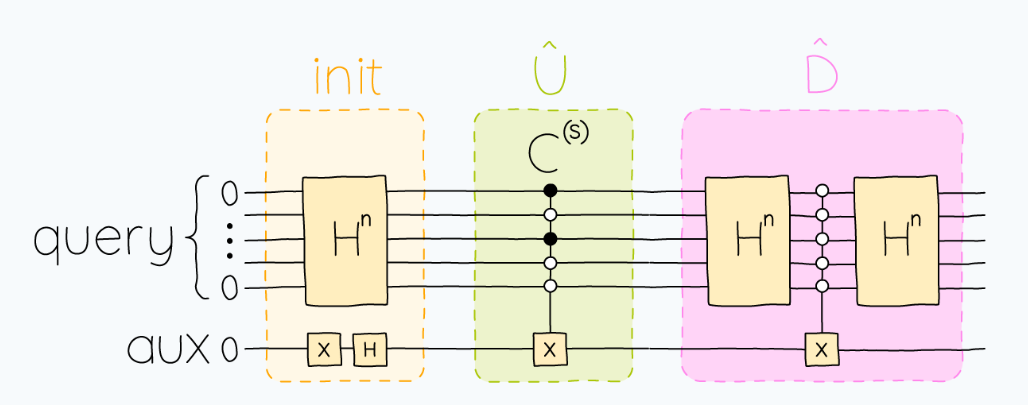

### Steps and Speedups

In [ ]:
"""
G.4.1a Make a guess
"""
def grover_iter(combo, num_steps):
    """Run Grover search for a given secret combination and a number of iterations.

    Args:
        combo (list[int]): The secret combination, represented as a list of bits.
        num_steps (int): The number of Grover iterations to perform.

    Returns:
        array[float]: Probability for observing different outcomes.
    """
    n_bits = len(combo)
    query_register = list(range(n_bits))
    aux = [n_bits]
    all_wires = query_register + aux
    dev = qml.device("default.qubit", wires=all_wires)

    @qml.qnode(dev)
    def inner_circuit():
        # IMPLEMENT THE GROVER CIRCUIT

        # Prepare Qubits
        qml.PauliX(aux)
        hadamard_transform(all_wires)
        # Apply Grover algorithm
        for _ in range(num_steps):
            oracle(combo)
            diffusion(n_bits)

        return qml.probs(wires=query_register)

    return inner_circuit()

"""
G.4.1b Optimal number of iterations
"""
n_list = range(3, 7)
opt_steps = []

for n_bits in n_list:
    combo = [0] * n_bits  # A simple combination
    step_list = range(1, 100)  # Try out some large number of steps
    
    probs = [grover_iter(combo, step)[0] for step in step_list]
    opt_steps.append(local_max_arg(probs))
    # points.append(max(grover_circuit_n([0,0,1],i)))
    
print("The optimal number of Grover steps for qubits in", [3, 4, 5, 6], "is", opt_steps, ".")

"""
G.4.2 Finding the scaling power
"""
grad = 0.5
intercept = -0.47
# SUBMIT TO PLOT GRAPH


### Multiple Solutions

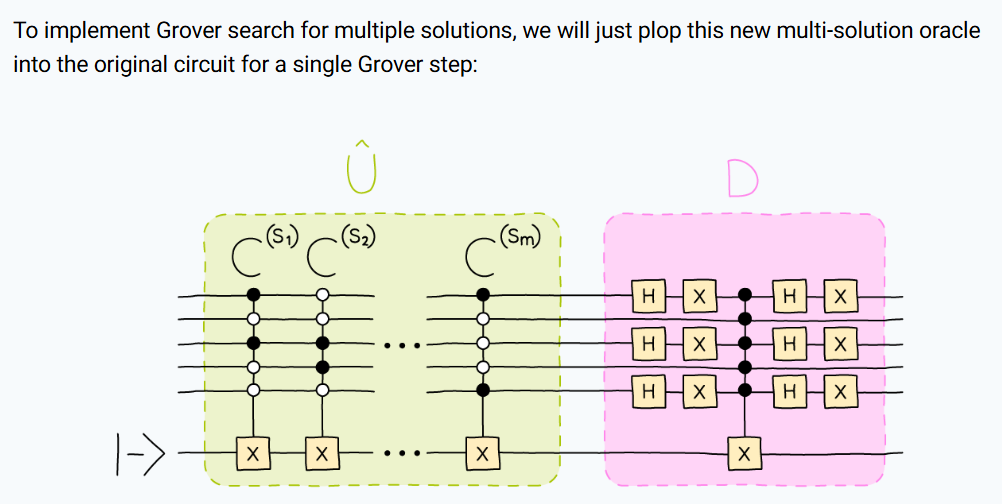

In [ ]:
"""
G.5.1 Preparing a multi-solution oracle
"""
n_bits = 5
query_register = list(range(n_bits))
aux = [n_bits]
all_wires = query_register + aux
dev = qml.device("default.qubit", wires=all_wires)


def oracle_multi(combos):
    """Implement multi-solution oracle using sequence of multi-controlled X gates.

    Args:
        combos (list[list[int]]): A list of solutions.
    """
    for combo in combos:
        # Not needed for this new version of Pennylane: combo_str = "".join(str(j) for j in combo)
        
        qml.MultiControlledX(all_wires, combo)

"""
G.5.2a Optimal steps for many solutions
"""
n_bits = 5
query_register = list(range(n_bits))
aux = [n_bits]
all_wires = query_register + aux
dev = qml.device("default.qubit", wires=all_wires, shots=None)


def grover_iter_multi(combos, num_steps):
    """Run Grover search for multiple secret combinations and a number
    of Grover steps.

    Args:
        combos (list[int]): The secret combination, represented as a list of bits.
        num_steps (int): The number of Grover iterations to perform.

    Returns:
        array[float]: Probability for observing different outcomes.
    """

    @qml.qnode(dev)
    def inner_circuit():
        qml.PauliX(aux)
        hadamard_transform(all_wires)

        for _ in range(num_steps):
            oracle_multi(combos)
            diffusion(n_bits)
        return qml.probs(wires=query_register)

    return inner_circuit()

"""
G.5.2b Sampling step number data
"""
m_list = range(3)
opt_steps = []

# n_bits are the number of query qubits

for m_bits in m_list:
    # combos are the first M (2^m_bits) integers as the solutions
    combos = [[int(s) for s in np.binary_repr(j, n_bits)] for j in range(2**m_bits)]
    step_list = range(1, 10)
    
    # sum over the first M solutions
    probs = [sum(grover_iter_multi(combos, step)[:2**m_bits]) for step in step_list]
    opt_steps.append(local_max_arg(probs))

print("The optimal number of Grover steps for the number of solutions in", [1, 2, 4], "is", opt_steps, ".")

"""
G.5.3 The scaling power
"""
grad = -0.5
intercept = 2.03
# SUBMIT TO PLOT GRAPH


## F. Quantum Fourier Transform
### Changing Perspectives

In [ ]:
"""
F.1.1 Converting to value representation
"""
def coefficients_to_values(coefficients):
    """Returns the value representation of a polynomial
    
    Args:
        coefficients (array[complex]): a 1-D array of complex 
            coefficients of a polynomial with 
            index i representing the i-th degree coefficient

    Returns: 
        array[complex]: the value representation of the 
            polynomial 
    """
    return np.fft.fft(coefficients)

A = [4, 3, 2, 1]
print(coefficients_to_values(A))

"""
F.1.2 Converting to coefficient representation
"""
def values_to_coefficients(values):
    """Returns the coefficient representation of a polynomial
    
    Args:
        values (array[complex]): a 1-D complex array with 
            the value representation of a polynomial 

    Returns: 
        array[complex]: a 1-D complex array of coefficients
    """
    
    return np.fft.ifft(values)


A = [10.+0.j,  2.-2.j,  2.+0.j,  2.+2.j]
print(values_to_coefficients(A))

"""
F.1.3 The nearest power of 2
"""
def nearest_power_of_2(x):
    """Given an integer, return the nearest power of 2. 
    
    Args:
        x (int): a positive integer

    Returns: 
        int: the nearest power of 2 of x
    """
    # Note: np.ceil() rounds up ("ceiling")
    return 2**int(np.ceil(np.log2(x)))

"""
F.1.4 Multiplying polynomials
"""
def fft_multiplication(poly_a, poly_b):
    """Returns the result of multiplying two polynomials
    
    Args:
        poly_a (array[complex]): 1-D array of coefficients 
        poly_b (array[complex]): 1-D array of coefficients 

    Returns: 
        array[complex]: complex coefficients of the product
            of the polynomials
    """
    ##################
    # YOUR CODE HERE #
    ################## 

    # Calculate the number of values required
    n = nearest_power_of_2(len(poly_a) + len(poly_b) - 1)    

    # Pad zeros to the polynomial
    # we pad with 0 zeros at the start, and n - len(pol) zeros at the end
    # by default constand_values = 0 (which you must indicat at the end)
    padded_a = np.pad(poly_a, (0, n - len(poly_a)), mode="constant")
    padded_b = np.pad(poly_b, (0, n - len(poly_b)), mode="constant")

    # Convert the polynomials to value representation 
    values_a = coefficients_to_values(padded_a)
    values_b = coefficients_to_values(padded_b)

    # Multiply
    values = values_a * values_b

    # Convert back to coefficient representation
    coeffs_multi = values_to_coefficients(values)
    
    return np.real(coeffs_multi)

### Quantum Fourier Transform

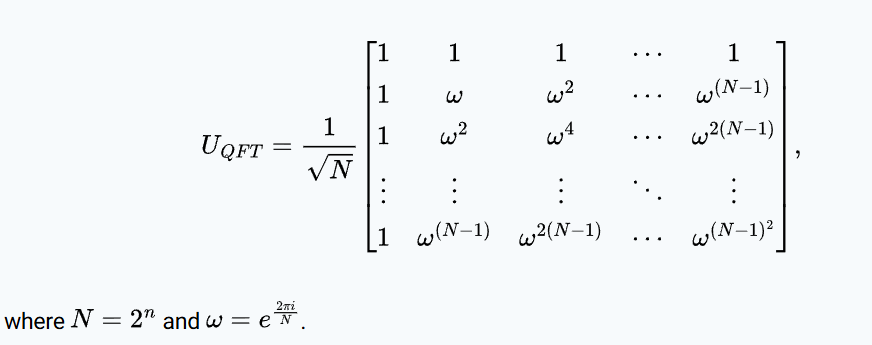

In [ ]:
"""
F.2.1 The QFT for one qubit
"""
num_wires = 1
dev = qml.device("default.qubit", wires=num_wires)

@qml.qnode(dev)
def one_qubit_QFT(basis_id):
    """A circuit that computes the QFT on a single qubit. 
    
    Args:
        basis_id (int): An integer value identifying 
            the basis state to construct.
    
    Returns:
        array[complex]: The state of the qubit after applying QFT.
    """
    # Prepare the basis state |basis_id>
    bits = [int(x) for x in np.binary_repr(basis_id, width=num_wires)]
    qml.BasisState(bits, wires=[0])

    ##################
    # YOUR CODE HERE #
    ##################
    N = 2**num_wires
    omega = np.exp(2 * np.pi * 1j / N)

    U_QFT = np.array([omega**(i*j) for i in range(N) for j in range(N)]).reshape((N, N)) / np.sqrt(N)
    qml.QubitUnitary(U_QFT, wires=0)
    
    return qml.state()

"""
F.2.2 The QFT for two qubits
"""
num_wires = 2
dev = qml.device("default.qubit", wires=num_wires)

@qml.qnode(dev)
def two_qubit_QFT(basis_id):
    """A circuit that computes the QFT on two qubits using qml.QubitUnitary. 
    
    Args:
        basis_id (int): An integer value identifying the basis state to construct.
    
    Returns:
        array[complex]: The state of the qubits after the QFT operation.
    """
    
    # Prepare the basis state |basis_id>
    bits = [int(x) for x in np.binary_repr(basis_id, width=num_wires)]
    qml.BasisState(bits, wires=[0, 1])
    
    ##################
    # YOUR CODE HERE #
    ##################
    N = 2**num_wires
    omega = np.exp(2 * np.pi * 1j / N)

    U_QFT = np.array([omega**(i*j) for i in range(N) for j in range(N)]).reshape((N, N)) / np.sqrt(N)
    qml.QubitUnitary(U_QFT, wires=[0, 1])    # only change
    
    return qml.state()

"""
F.2.3 The QFT circuit
"""
num_wires = 2
dev = qml.device("default.qubit", wires=num_wires)

@qml.qnode(dev)
def decompose_two_qubit_QFT(basis_id):
    """A circuit that computes the QFT on two qubits using elementary gates.
    
    Args:
        basis_id (int): An integer value identifying the basis state to construct.
    
    Returns:
        array[complex]: The state of the qubits after the QFT operation.
    """
    # Prepare the basis state |basis_id>
    bits = [int(x) for x in np.binary_repr(basis_id, width=num_wires)]
    qml.BasisState(bits, wires=[0, 1])
    
    qml.Hadamard(wires=0)
    qml.ctrl(qml.S, control=1)(wires=0)
    qml.Hadamard(wires=1)
    qml.SWAP(wires=[0, 1])
    
    return qml.state()

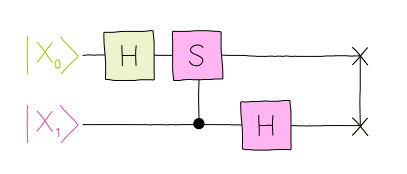

### Connecting the Dots

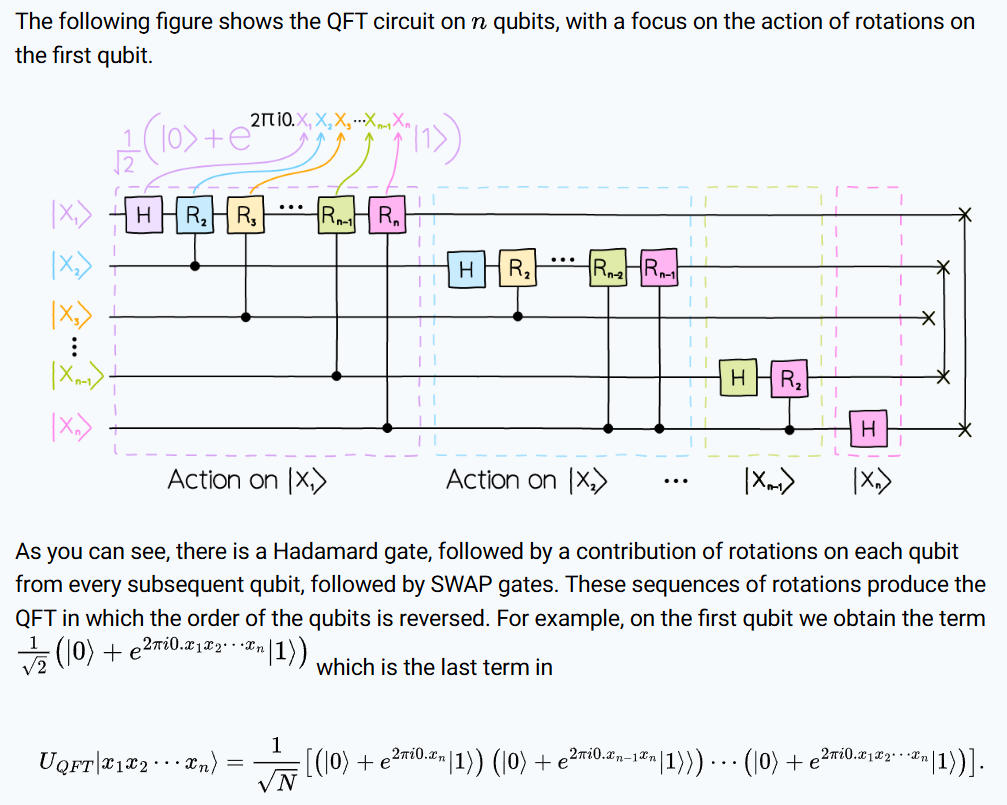

In [ ]:
"""
F.3.1 The 3-qubit QFT
"""
num_wires = 3
dev = qml.device("default.qubit", wires=num_wires)

@qml.qnode(dev)
def three_qubit_QFT(basis_id):
    """A circuit that computes the QFT on three qubits.
    
    Args:
        basis_id (int): An integer value identifying the basis state to construct.
        
    Returns:
        array[complex]: The state of the qubits after the QFT operation.
    """
    # Prepare the basis state |basis_id>
    bits = [int(x) for x in np.binary_repr(basis_id, width=num_wires)]
    qml.BasisState(bits, wires=[0, 1, 2])
    
    qml.Hadamard(0)
    qml.ctrl(qml.S, control=1)(0)
    qml.ctrl(qml.T, control=2)(0)

    qml.Hadamard(1)
    qml.ctrl(qml.S, control=2)(1)

    qml.Hadamard(2)
    qml.SWAP([0, 2])

    return qml.state()

"""
F.3.2 Swapping qubits
"""
dev = qml.device('default.qubit', wires=4)

            
def swap_bits(n_qubits):
    """A circuit that reverses the order of qubits, i.e.,
    performs a SWAP such that [q1, q2, ..., qn] -> [qn, ... q2, q1].
    
    Args:
        n_qubits (int): An integer value identifying the number of qubits.
    """
    for i in range(n_qubits // 2):
        qml.SWAP(wires=[i, n_qubits - i -1])

@qml.qnode(dev) 
def qft_node(basis_id, n_qubits):
    # Prepare the basis state |basis_id>
    bits = [int(x) for x in np.binary_repr(basis_id, width=n_qubits)]
    qml.BasisState(bits, wires=range(n_qubits))
    # qft_rotations(n_qubits)
    swap_bits(n_qubits)
    return qml.state()

"""
F.3.3 Putting the QFT together
"""
dev = qml.device('default.qubit', wires=4)

def qft_rotations(n_qubits):
    """A circuit performs the QFT rotations on the specified qubits.
    
    Args:
        n_qubits (int): An integer value identifying the number of qubits.
    """
    # Note: ControlledPhaseShift(phi, wires, id=None)
    # phi = angle of rotation (without the imaginary number i)
    # wires, with the first wire provided corresponding to the control qubit

    # We apply a Hadamard followed by a series of controlled rotations 
    # that get smaller by half for every qubit further away you go
    for i in range(n_qubits):
        qml.Hadamard(i)
        for j in range(i+1, n_qubits):
            k = j - i + 1 # for R2 (neighbour qubits: j-i=1), 
                          # we apply a S gate which has k = 2 (st angle is pi/2), and so on...
            qml.ControlledPhaseShift(2*np.pi / 2**k, wires=[j, i])

@qml.qnode(dev) 
def qft_node(basis_id, n_qubits):
    # Prepare the basis state |basis_id>
    bits = [int(x) for x in np.binary_repr(basis_id, width=n_qubits)]
    qml.BasisState(bits, wires=range(n_qubits))
    qft_rotations(n_qubits)
    swap_bits(n_qubits)
    return qml.state()

"""
F.3.4 A recursive solution
"""
dev = qml.device('default.qubit', wires=4)

def qft_recursive_rotations(n_qubits, wire=0):
    """A circuit that performs the QFT rotations on the specified qubits
        recursively.
        
    Args:
        n_qubits (int): An integer value identifying the number of qubits.
        wire (int): An integer identifying the wire 
                    (or the qubit) to apply rotations on.
    """

    if n_qubits <= 0:
        return
    qml.Hadamard(wire)
    for j in range(1, n_qubits):
        k = j - 0 + 1
        qml.ControlledPhaseShift(2*np.pi / 2**k, wires=[wire + j, wire])

    qft_recursive_rotations(n_qubits - 1, wire + 1)

        

@qml.qnode(dev) 
def qft_node(basis_id, n_qubits):
    # Prepare the basis state |basis_id>
    bits = [int(x) for x in np.binary_repr(basis_id, width=n_qubits)]
    qml.BasisState(bits, wires=range(n_qubits))
    qft_recursive_rotations(n_qubits)
    swap_bits(n_qubits)
    return qml.state()

"""
F.3.5 The QFT in PennyLane
"""
dev = qml.device('default.qubit', wires=4)

@qml.qnode(dev)
def pennylane_qft(basis_id, n_qubits):
    """A that circuit performs the QFT using PennyLane's QFT template.
    
    Args:
        basis_id (int): An integer value identifying 
            the basis state to construct.
        n_qubits (int): An integer identifying the 
            number of qubits.
            
    Returns:
        array[complex]: The state after applying the QFT to the qubits.
    """
    # Prepare the basis state |basis_id>
    bits = [int(x) for x in np.binary_repr(basis_id, width=n_qubits)]
    qml.BasisState(bits, wires=range(n_qubits))

    qml.QFT(wires=range(n_qubits))
    return qml.state()


## P. Quantum Phase Estimation

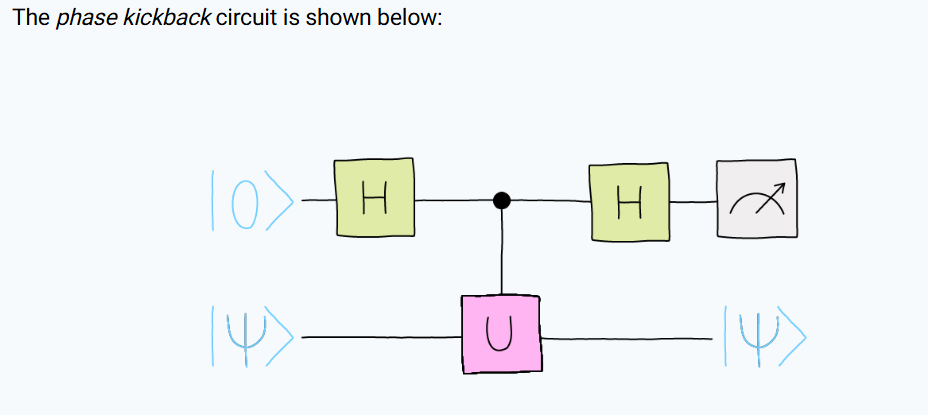

### Catch the Phase

In [ ]:
"""
P.1.1 Detecting a negative phase
"""
dev = qml.device("default.qubit", wires=2)

@qml.qnode(dev)
def guess_the_unitary(unitary):
    """Given a unitary that performs a Z or a -Z operation
    on a qubit, guess which one it is.
    
    Args: 
        U (array[complex]): A unitary matrix, guaranteed to be either Z or -Z.
    
    Returns:
        array [int]:  Probabilities on  on the first qubit
        using qml.probs()
    """
    qml.Hadamard(0)
    qml.ctrl(qml.QubitUnitary(unitary, wires=1), control=0)
    qml.Hadamard(0)
    return qml.probs(wires=0)

# Z gate 
# U = qml.PauliZ.compute_matrix() 

# -Z gate
U = (-1)*qml.PauliZ.compute_matrix()

print(guess_the_unitary(U))

"""
P.1.2 Finding the eigenvalues of Pauli X
"""
dev = qml.device("default.qubit", wires=2)
        
@qml.qnode(dev)
def phase_kickback_X(eigenvector):
    """ Given an eigenvector of X, 
    apply the phase kickback circuit to observe 
    the probabilities on the control wire
    
    Args: 
        eigenvector(String): A string "plus" or "minus" depicting 
        the eigenvector of X
    
    Returns:
        array[int]: Measurement outcome on the first qubit using qml.probs()
    """
    # Prepare |ψ>
    if eigenvector == "plus":
        qml.Hadamard(wires=1)
    else:
        qml.PauliX(wires=1)
        qml.Hadamard(wires=1)
    
    # Phase kickback
    qml.Hadamard(0)
    qml.CNOT(wires=[0, 1])
    qml.Hadamard(0)
 
    return qml.probs(wires=[0])   

print(phase_kickback_X("plus"))
print(phase_kickback_X("minus"))

# MODIFY EIGENVALUES BELOW 
eigenvalue_of_X_plus = 1
eigenvalue_of_X_minus = -1


### It's not Just a Phase

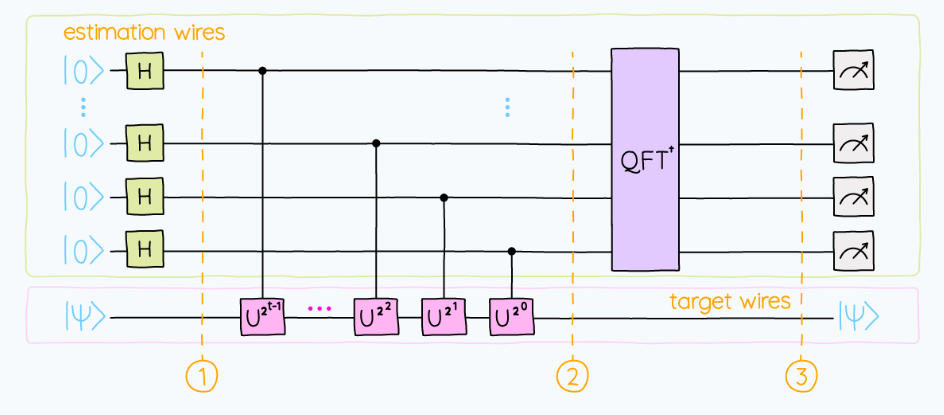

In [ ]:
"""
P.2.1 Powers of U
"""
def U_power_2k(unitary, k):
    """ Computes U at a power of 2k (U^2^k)
    
    Args: 
        unitary (array[complex]): A unitary matrix
    
    Returns: 
        array[complex]: the unitary raised to the power of 2^k
    """
    
    return np.linalg.matrix_power(unitary, 2**k)
            

# Try out a higher power of U
U = qml.T.compute_matrix()
print(U)

U_power_2k(U, 5)

"""
P.2.2 Controlled powers of U
"""
estimation_wires = [0, 1, 2]
target_wires = [3]

def apply_controlled_powers_of_U(unitary):
    """A quantum function that applies the sequence of powers of U^2^k to
    the estimation wires.
    
    Args: 
        unitary (array [complex]): A unitary matrix
    """

    t = len(estimation_wires)
    # Note: ControlledQubitUnitary(unitary, wires, control_wires)
    # with the wires = the full controlled unitary acts on, composed of 
    #                  the controlled wires followed by the target wire.
    for k in range(t):
        U = U_power_2k(unitary, t-1-k)
        target_control = [estimation_wires[k]] + target_wires
        qml.ControlledQubitUnitary(U, wires = target_control)
        
        

"""
P.2.3 The full QPE circuit
"""
dev = qml.device("default.qubit", wires=4)

estimation_wires = [0, 1, 2]
target_wires = [3]

def prepare_eigenvector():
    qml.PauliX(wires=target_wires)

@qml.qnode(dev)
def qpe(unitary):
    """ Estimate the phase for a given unitary.
    
    Args:
        unitary (array[complex]): A unitary matrix.
        
    Returns:
        array[float]: Measurement outcome probabilities on the estimation wires.
    """
    prepare_eigenvector()

    [qml.Hadamard(wire) for wire in estimation_wires]

    apply_controlled_powers_of_U(unitary)

    qml.adjoint(qml.QFT)(wires=estimation_wires)

    return qml.probs(wires=estimation_wires)
    

U = qml.T.compute_matrix()
print(qpe(U))

"""
P.2.4 Computing the phase
"""
estimation_wires = [0, 1, 2]
target_wires = [3]

def estimate_phase(probs):
    """Estimate the value of a phase given measurement outcome probabilities
    of the QPE routine.
    
    Args: 
        probs (array[float]): Probabilities on the estimation wires.
    
    Returns:
        float: the estimated phase   
    """
    phase = 0
    n = len(estimation_wires)

    for idx, p in enumerate(probs):
        # QPE encodes the phase in the binary representation of that integer
        theta = np.binary_repr(idx, width=n)    # = theta_k
        # If n=3 and idx=6, np.binary_repr turns it into '110'
        # This string corresponds to the binary fraction $0.110_2$
        # ----> $\theta_1=1, \theta_2=1, \theta_3=0$
        for k in range(n):
            phase += int(theta[k]) / 2**(k + 1) * p    # we multipy by p bc this is an expectation value (estimation)

    return float(phase)
    
U = qml.T.compute_matrix()

probs = qpe(U)


estimated_phase = estimate_phase(probs)
print(estimated_phase)

"""
P.2.5 QPE in PennyLane
"""
dev = qml.device("default.qubit", wires=4)

estimation_wires = [0, 1, 2]
target_wires = [3]

def prepare_eigenvector():
    qml.PauliX(wires=target_wires)

@qml.qnode(dev)
def qpe(unitary):
    """Estimate the phase for a given unitary.
    
    Args:
        unitary (array[complex]): A unitary matrix.
        
    Returns:
        array[float]: Probabilities on the estimation wires.
    """
    
    prepare_eigenvector()
    
    qml.QuantumPhaseEstimation(unitary, estimation_wires=estimation_wires, target_wires=target_wires)

    return qml.probs(estimation_wires)


U = qml.T.compute_matrix()
probs = qpe(U)
print(estimate_phase(probs))


### Let's Be Rational

In [ ]:
"""
P.3.1 Sampling for the phase
"""
dev = qml.device("default.qubit", wires=10)


def fractional_binary_to_decimal(binary_fraction, wires):
    # np.argsort(probs) returs integers which 
    # we have turn back into phase values between 0 and 1 (decimals)
    # ex. If we are using 3 qubits, index 5 (binary 101) corresponds to 
    #     the phase $\frac{5}{2^3} = \frac{5}{8} = 0.625$
    return float(binary_fraction/ 2 ** len(wires))

def phase_window(probs, estimation_wires):
    """ Given an array of probabilities, return the phase window of the 
    unitary's eigenvalue
    
    Args: 
        probs (array[float]): Probabilities on the estimation wires.
        estimation_wires (list[int]): List of estimation wires
    
    Returns:
        (float, float): the lower and upper bound of the phase
    """

    # Note: np.argsort(probs) sorts the indices of the array 
    # based on their values, from lowest probability to highest
    # bound 1 and 2 are the highest and second higest states (with the highest probs)
    
    bound_1 = fractional_binary_to_decimal(np.argsort(probs)[-1], estimation_wires) # MOST LIKELY OUTCOME
    bound_2 = fractional_binary_to_decimal(np.argsort(probs)[-2], estimation_wires) # SECOND MOST LIKELY OUTCOME
    return (bound_1, bound_2)


# Test your solution

# You can increase the number of estimation wires to a maximum of range(0, 9)
estimation_wires = range(0, 9)

# The target is set to the last qubit
target_wires = [9]

# Define the unitary
U = np.array([[1, 0], [0, np.exp((2*np.pi*1j/7))]])

probs = qpe(U, estimation_wires, target_wires)

print(phase_window(probs, estimation_wires))

# MODIFY TO TRUE AFTER TESTING YOUR SOLUTION
done = True

"""
P.3.2 Improving the estimates
"""
dev = qml.device("default.qubit", wires=10)

def estimates_array(unitary):
    """ Given a unitary, return a list of its phase windows
    
    Args: 
        unitary (array[complex]): A unitary matrix.
    
    Returns:
        [(float, float)]: a list of phase windows for 2 to 9 
        estimation wires
    """

    estimates = []
    target_wires = [9]

    for n in range(2, 10):
        estimation_wires = range(n)
        probs = qpe(unitary, estimation_wires, target_wires)
        estimates.append(phase_window(probs, estimation_wires))

    return estimates

# Define the unitary
U = np.array([[1, 0], [0, np.exp((2*np.pi*1j/7))]])

estimates_array(U)

###################
# SUBMIT FOR PLOT #
###################


### A Mixed Bag

In [ ]:
"""
P.4.1 Eigenphases of the T-gate
"""
dev = qml.device("default.qubit", wires=5)
estimation_wires = [0, 1, 2]
target_wires = [3]

def prepare_eigenvector_superposition(alpha, beta):
    # Normalize alpha and beta
    norm_squared = np.abs(alpha) ** 2 + np.abs(beta) ** 2
    norm = np.sqrt(norm_squared)
    state = np.array([alpha/norm, beta/norm])
    
    # Prepare the state
    qml.MottonenStatePreparation(state, wires=target_wires)


@qml.qnode(dev)
def qpe(unitary):
    """Estimate the phase for a given unitary.
    
    Args:
        unitary (array[complex]): A unitary matrix.

    Returns:
        array[float]: Probabilities on the estimation wires.
    """
    
    # MODIFY ALPHA, BETA TO PREPARE EIGENVECTOR    
    # prepare_eigenvector_superposition(0, 1)
    #prepare_eigenvector_superposition(1, 0)
    prepare_eigenvector_superposition(1/np.sqrt(2), 1/np.sqrt(2))

    qml.QuantumPhaseEstimation(
        unitary,
        target_wires=target_wires,
        estimation_wires=estimation_wires,
    )
    return qml.probs(wires=estimation_wires)

U = qml.T.compute_matrix()

probs = qpe(U)

# MODIFY TO TRUE WHEN YOU ARE DONE TESTING
done = True

"""
P.4.2 Eigenphases of a two-qubit gate
"""
dev = qml.device("default.qubit", wires=5)
estimation_wires = [0, 1, 2]
target_wires = [3, 4]

def prepare_eigenvector_superposition(alpha, beta, gamma, delta):
    # Normalize alpha, beta, gamma, and delta
    norm_squared = np.abs(alpha) ** 2 + np.abs(beta) ** 2 + np.abs(gamma) ** 2 + np.abs(delta) ** 2 
    norm = np.sqrt(norm_squared)
    state = np.array([alpha/norm, beta/norm, gamma/norm, delta/norm])
    
    #Prepare the state
    qml.MottonenStatePreparation(state, wires=target_wires)


@qml.qnode(dev)
def qpe(unitary):
    """Estimate the phase for a given unitary.
    
    Args:
        unitary (array[complex]): A unitary matrix.

    Returns:
        array[float]: Probabilities on the estimation wires.
    """
    
    # PREPARE EIGENVECTOR
    # prepare_eigenvector_superposition(0, 0, 0, 1)
    # prepare_eigenvector_superposition(1, 0, 0, 0)
    prepare_eigenvector_superposition(1, 1, 1, 1)
    
    
    qml.QuantumPhaseEstimation(
        unitary,
        target_wires=target_wires,
        estimation_wires=estimation_wires,
    )
    return qml.probs(wires=estimation_wires)


U = qml.CZ.compute_matrix()

probs = qpe(U)

# MODIFY TO PROBABILITY OF OBSERVING 100 WHEN ESTIMATION 
# WIRES ARE IN EQUAL SUPERPOSITION
probability_100 = 0.25

# NOTE ON THE OUTPUT GRAPH:
# The Quantum Phase Estimation (QPE) algorithm sorts your input superposition into "bins" based on their phase.

# The Input: Equal superposition of 4 states ($|00\rangle, |01\rangle, |10\rangle, |11\rangle$). 
#            Each contributes 25% (0.25) of the probability.
# The Filter: The $CZ$ gate applies a phase of 0.5 (which corresponds to binary 100) only to the $|11\rangle$ state (it flips the sign), while the rest are untouched (phase = 0).
# The Result: Since $|11\rangle$ is the only state with this phase, the 100 bin captures exactly its 25% share of the probability. The other 75% of the states ($|00\rangle, |01\rangle, |10\rangle$) have phase 0 and land in the 000 bin.

"""
P.4.3 Experimenting with more unitaries
"""
dev = qml.device("default.qubit", wires=6)
estimation_wires = [0, 1, 2, 3]
target_wires = [4, 5]

def prepare_eigenvector_superposition(alpha, beta, gamma, delta):
    # Normalize alpha, beta, gamma, and delta
    norm_squared = np.abs(alpha) ** 2 + np.abs(beta) ** 2 + np.abs(gamma) ** 2 + np.abs(delta) ** 2 
    norm = np.sqrt(norm_squared)
    state = np.array([alpha/norm, beta/norm, gamma/norm, delta/norm])
    
    # Prepare the state
    qml.MottonenStatePreparation(state, wires=target_wires)


@qml.qnode(dev)
def qpe(unitary):
    """Estimate the phase for a given unitary.
    
    Args:
        unitary (array[complex]): A unitary matrix.

    Returns:
        probs (array[float]): Probabilities on the estimation wires.
    """
    
    # MODIFY ALPHA, BETA, GAMMA, DELTA TO PREPARE EIGENVECTOR 
    # prepare_eigenvector_superposition(0, 0, 0, 1)
    # prepare_eigenvector_superposition(1, 0, 0, 0)
    # prepare_eigenvector_superposition(0, 1, 0, 0)
    # OR UNCOMMENT LINES ABOVE TO PREPARE THE STATE OF YOUR CHOICE
    prepare_eigenvector_superposition(1, 1, 1, 1)
    
    qml.QuantumPhaseEstimation(
        unitary,
        target_wires=target_wires,
        estimation_wires=estimation_wires,
    )
    return qml.probs(wires=estimation_wires)


# UNCOMMENT THE LINE CORRESPONDING TO THE MATRIX YOU'D LIKE 
# TO ESTIMATE PHASES OF
# U = qml.CZ.compute_matrix()
# U = qml.CRZ.compute_matrix(0.4)
U = qml.CRX.compute_matrix(1/3)
# U = qml.CRot.compute_matrix(0.9, 0.7, 0.4)

probs = qpe(U)

# We observe that for the CRX gate with rot angle 1/3, the 2nd highest prob basis state is 1111
outcome_integer = int("1111", 2)
resolution = 2 ** len(estimation_wires)

mystery_phase = outcome_integer / resolution # MODIFY THIS


## S. Shor's Algorithm
### Modular Arithmetic

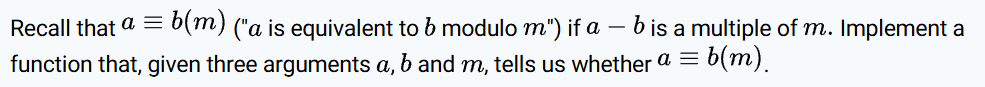
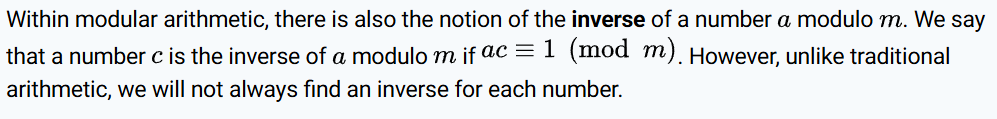

In [ ]:
"""
S.1.1 Modular equivalence
"""
def is_equivalent(a, b, m):
    """Return a boolean indicating whether the equivalence is satisfied.

    Args:
        a (int): First number to check the equivalence.
        b (int): Second number to check the equivalence.
        m (int): Modulus of the equivalence.

    Returns:
        bool: True if a = b (m), False otherwise.
    """
    # note: a % m is the modulo operator: it calculates the remainder when you divide a by m
    return a % m == b % m


print(f"13 = 8 (3) is {is_equivalent(13, 8, 3)}")
print(f"13 = 7 (6) is {is_equivalent(13, 7, 6)}")

"""
S.1.2 The inverse of modular arithmetic
"""
def has_inverse(a, m):
    """Returns a boolean indicating whether a number has an inverse modulo m.

    Args:
        a (int): Number to find the inverse modulus m.
        m (int): Modulus of the equivalence.

    Returns:
        bool: True if c exists (ac = 1 (m)), False otherwise
    """

    for c in range(m):
        if a * c % m ==1:
            return True

    return False


print("(5,15)", has_inverse(5, 15))
print("(7,15)", has_inverse(7, 15))


13 = 8 (3) is False
13 = 7 (6) is True


'\nS.1.2 The inverse of modular arithmetic\n'

### Classical Factorization
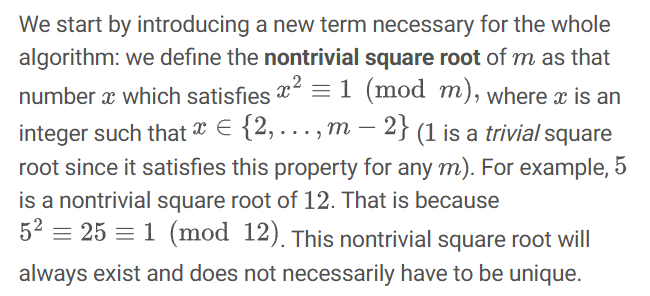

In [ ]:
"""
S.2.1 Nontrivial square roots
"""
def nontrivial_square_root(m):
    """Return the first nontrivial square root modulo m.

    Args:
        m (int): modulus for which want to find the nontrivial square root

    Returns:
        int: the first nontrivial square root of m
    """

    for i in range(2, m):
        if i**2 % m == 1:
            return i
    return -1


print(nontrivial_square_root(391))

"""
S.2.2 Prime factors
"""
def factorization(N):
    """Return the factors of N.

    Args:
        N (int): number we want to factor.

    Returns:
        array[int]: [p,q] factors of N.
    """
    nt_sqrt = nontrivial_square_root(N)

    p = np.gcd(nt_sqrt-1, N)
    q = np.gcd(nt_sqrt+1, N)
    return p, q

N = 391
p, q = factorization(N)
print(f"{N} = {p} x {q}")


### Period Finding

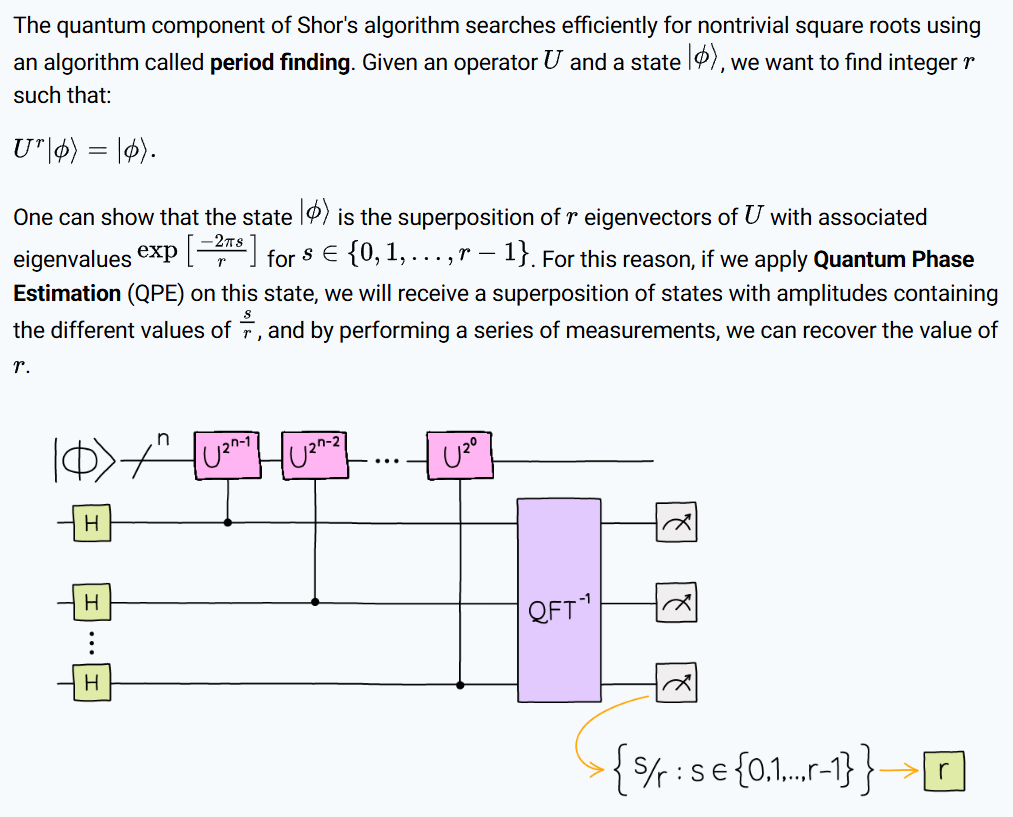

In [ ]:
"""
S.3.1 The QPE component
"""
def U():
    qml.SWAP(wires=[2, 3])
    qml.SWAP(wires=[1, 2])
    qml.SWAP(wires=[0, 1])
    for i in range(4):
        qml.PauliX(wires=i)


matrix = qml.matrix(U, wire_order=range(4))()

n_target_wires = 4
target_wires = range(n_target_wires)
n_estimation_wires = 3
estimation_wires = range(4, 4 + n_estimation_wires)


dev = qml.device("default.qubit", shots=1, wires=n_target_wires + n_estimation_wires)


@qml.qnode(dev)
def circuit(matrix):
    """Return a sample after taking a shot at the estimation wires.

    Args:
        matrix (array[complex]): matrix representation of U.

    Returns:
        array[float]: a sample after taking a shot at the estimation wires.
    """

    # CREATE THE INITIAL STATE |0001> ON TARGET WIRES
    qml.PauliX(wires = target_wires[-1])

    # USE THE SUBROUTINE QUANTUM PHASE ESTIMATION
    qml.QuantumPhaseEstimation(matrix, estimation_wires=estimation_wires, target_wires=target_wires)

    return qml.sample(wires=estimation_wires)


def get_phase(matrix):
    binary_arr = circuit(matrix)
    print(binary_arr)
    binary = "".join([str(b) for b in binary_arr[0]])
    return int(binary, 2) / 2**n_estimation_wires


for i in range(5):
    print(f"shot {i+1}, phase:", get_phase(matrix))

"""
S.3.2 Determining the period
"""
def U():
    qml.SWAP(wires=[2, 3])
    qml.SWAP(wires=[1, 2])
    qml.SWAP(wires=[0, 1])
    for i in range(4):
        qml.PauliX(wires=i)


matrix = qml.matrix(U, wire_order=range(4))()

target_wires = range(4)
n_estimation_wires = 3
estimation_wires = range(4, 4 + n_estimation_wires)


def get_period(matrix):
    """Return the period of the state using the already-defined
    get_phase function.

    Args:
        matrix (array[complex]): matrix associated with the operator U

    Returns:
        int: Obtained period of the state.
    """

    shots = 10

    phases = [get_phase(matrix) for _ in range(shots)]
    # fractions.Fraction(x) computes the fraction of a float x, with the denominator
    # having a max value (limit) of 2**n_estimation_wires (our qubit capacity)
    phases_fraction = [fractions.Fraction(x).limit_denominator(2**n_estimation_wires) for x in phases]

    denominators = [x.denominator for x in phases_fraction]

    # least common multiple:
    lcm = 1
    for d in denominators:
        lcm = lcm * d // np.gcd(lcm, d) # use exact formula: lmc(a, b) = a * b / GCD(a, b)
    
    return lcm


print(get_period(matrix))

"""
S.3.3 A sanity check
"""
def U():
    qml.SWAP(wires=[2, 3])
    qml.SWAP(wires=[1, 2])
    qml.SWAP(wires=[0, 1])
    for i in range(4):
        qml.PauliX(wires=i)


dev = qml.device("default.qubit", wires=4)


@qml.qnode(dev)
def circuit():
    """Apply U four times to |0001> to verify this is the period.

    Returns:
        array[float]: probabilities of each basis state.
    """

    # Prepare |0001> state
    qml.PauliX(wires = 3)

    # Apply U 4 times
    for _ in range(4):
        U()


    return qml.probs(wires=range(4))


print(circuit())


### Shor's Algorithm

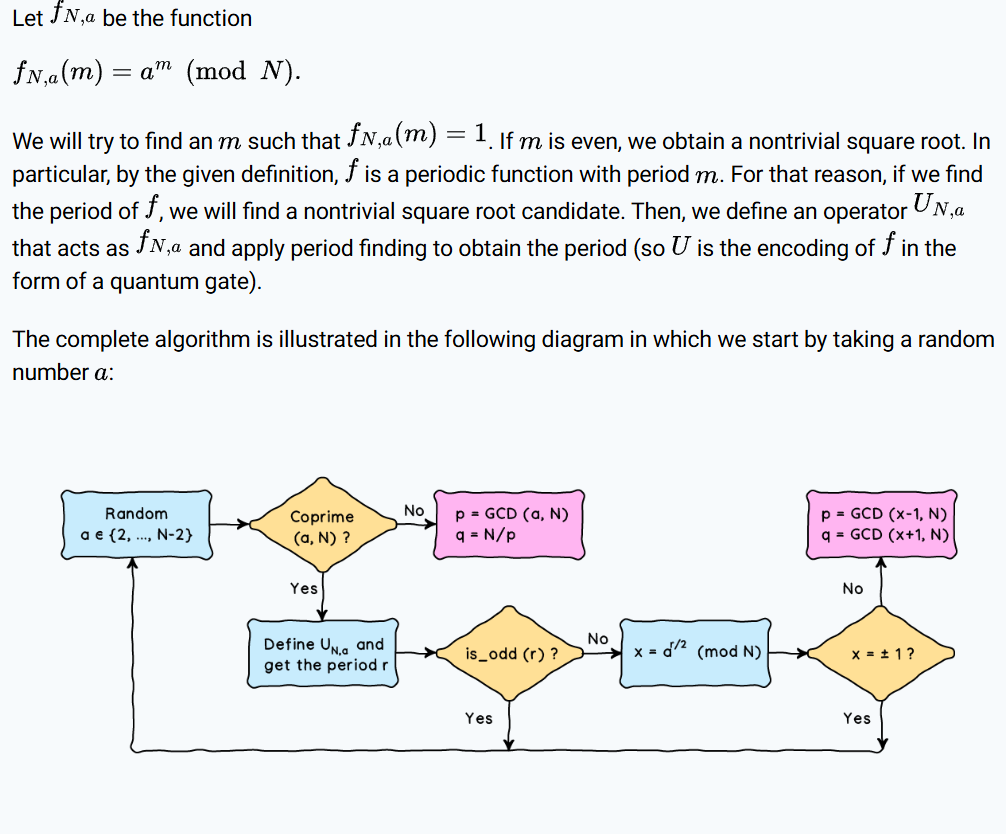

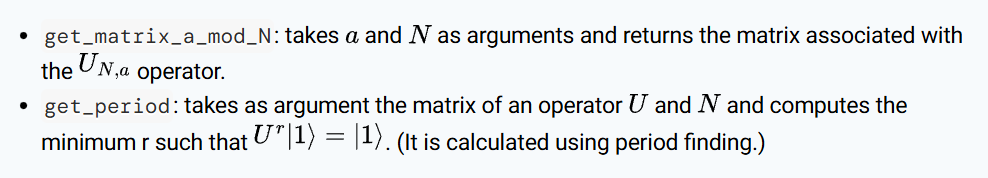

In [ ]:
"""
S.4.1 Period finding and square roots
"""
def is_coprime(a, N):
    """Determine if two numbers are coprime.

    Args:
        a (int): First number to check if is coprime with the other.
        N (int): Second number to check if is coprime with the other.

    Returns:
        bool: True if they are coprime numbers, False otherwise.
    """

    if np.gcd(a, N)==1:
        return True
    return False


def is_odd(r):
    """Determine if a number is odd.

    Args:
        r (int): Integer to check if is an odd number.

    Returns:
        bool: True if it is odd, False otherwise.
    """

    if r % 2 ==1:
        return True
    return False


def is_not_one(x, N):
    """Determine if x is not +- 1 modulo N.

    Args:
        N (int): Modulus of the equivalence.
        x (int): Integer to check if it is different from +-1 modulo N.

    Returns:
        bool: True if it is different, False otherwise.
    """

    # Note: In modular arithmetic, -1 wraps around to the end (that's why -1 = N-1)
    if x % N != 1 and x % N != N-1:
        return True
    return False


print("3 and 12 are coprime numbers: ", is_coprime(3, 12))
print("5 is odd: ", is_odd(5))
print("4 is not one mod 5: ", is_not_one(4, 5))

"""
S.4.2 Shor's algorithm
"""
def shor(N):
    """Return the factorization of a given integer.

    Args:
       N (int): integer we want to factorize.

    Returns:
        array[int]: [p,q], the prime factors of N.
    """

    for a in range(2, N):
        if is_coprime(a, N) == False:
            p = np.gcd(a, N)
            q = N // p
            return [p, q]

        U = get_matrix_a_mod_N(a, N)
        period_r = get_period(U, N)

        if is_odd(period_r) == False:
            x = (a**(period_r//2)) % N
            if is_not_one(x, N) == False:
                p = np.gcd(x-1, N)
                p = np.gcd(x+1, N)
                return [p, q]


print(shor(21))


### The RSA System

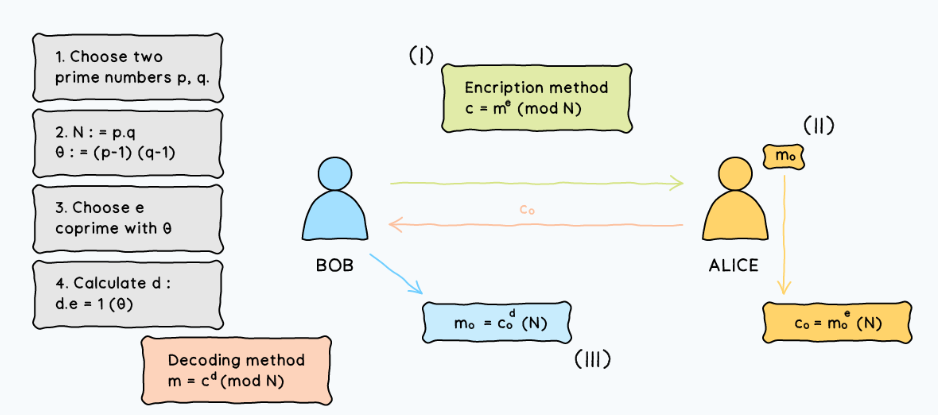

In [ ]:
"""
S.5.1 Encrypting a message
"""
def create_keys(p, q):
    """Returns the characteristic e, d and N values of RSA

    Args:
        p (int): First prime number of the algorithm.
        q (int): Second prime number of the algorithm.

    Returns:
        (int, int, int): a tuple consisting of the 'e' value of the RSA codification. 'd' value of the RSA decodification.
            and 'N', the product of p and q.
    """

    # Step 1: choose p and q
    # Step 2: Create N 
    N = p * q
    # Step 3: Choose e coprime with theta
    theta = (p-1) * (q - 1)

    # e coprime with theta:
    for e in range(2, N):
        if np.gcd(e, theta) == 1:
            # Step 4: compute d as the inverse of e
            d = pow(e, -1, theta)
            break

    return e, d, N
    


print(create_keys(3, 53))

"""
S.5.2 Decoding the message
"""
def decode(d, N, code):
    """Decode an encrypted message

    Args:
        d (int): Value of the RSA codification.
        N (int): Product of p and q.
        code list[int]: List of values to be decoded.

    Returns:
        string: Decoded message. (One character per list item)
    """

    message = ""

    for c in code:
        message += chr(pow(c, d, N))

    return message


code = [
    129827,
    294117,
    126201,
    157316,
    270984,
    126201,
    157316,
    270984,
    209269,
    163084,
    270984,
    157316,
    95353,
    289896,
    49377,
    95353,
    48004,
    270984,
    209269,
    95353,
    157316,
    157316,
    210673,
    267093,
    95353,
]

N = 378221
d = 150797


print(decode(d, N, code))
